# Geometric Metrics — a ten-problem set

**You implement. This notebook scaffolds.**

Ten problems, two datasets, one score. Every function whose body is
`raise NotImplementedError` is yours to write; the docstring gives you the
signature, the shapes and the formula in math notation — never the code. Every
`# VERIFICATION` cell is the judge: run it, don't edit it.

**The task, in all ten:** for each sample, retrieve its `K = 10` nearest
neighbours *excluding itself*, then score

$$\text{precision@}10(i) \;=\; \frac{1}{10}\sum_{j \,\in\, N_{10}(i)} \mathbf{1}\!\left[\,y_j = y_i\,\right]$$

and report the mean and std across all queries. One number, so ten metrics can
be put on one scoreboard.

**Two datasets, chosen to disagree:** 20newsgroups TF-IDF (cosine should win) and
`load_wine` standardised (Euclidean should win). A metric that wins on both is a
metric you have not tested hard enough.

---

### The set

| # | problem | difficulty | topics |
|---|---|---|---|
| 0 | [Retrieval Harness](#0) | Easy | `sorting`, `evaluation` |
| 1 | [TF-IDF + Cosine — the baseline](#1) | Medium | `linear-algebra`, `text` |
| 2 | [Euclidean on Unnormalised TF-IDF](#2) | Easy | `linear-algebra`, `text` |
| 3 | [L2-Normalise, then Euclidean](#3) | Medium | `proof`, `ranking` |
| 4 | [Minkowski Sweep over p](#4) | Medium | `linear-algebra`, `statistics` |
| 5 | [Weighted Cosine, `w = idf²`](#5) | Medium | `linear-algebra`, `text` |
| 6 | [Soft Cosine — the toy vocabulary](#6) | Medium | `linear-algebra`, `psd` |
| 6b | [Soft Cosine on the Real Corpus](#6b) | Hard | `sparse`, `embeddings` |
| 7 | [Mahalanobis on Wine](#7) | Hard | `covariance`, `whitening` |
| 8 | [Distance → Similarity, four ways](#8) | Easy | `monotonicity` |

**Solve them in order.** Problems 1–8 all call the harness from problem 0, and
problems 2–6 share the corpus built in problem 1. A bug in an early problem
looks like a metric result in every later one.

**Run the next cell once** — imports, the constants `K`, `SEED`, `CATEGORIES`,
and the `RESULTS` dict that each problem writes its score into. The scoreboard at
the bottom just reads it back.


In [16]:
from math import inf
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.constants import precision
from scipy.spatial.distance import cdist
from sklearn.datasets import fetch_20newsgroups, load_wine
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import StandardScaler, normalize

K = 10
CATEGORIES = ["alt.atheism", "comp.graphics", "sci.space", "talk.politics.mideast"]
SEED = 0
np.set_printoptions(precision=4, suppress=True)

# Every stage appends here; the final summary table just reads it.
RESULTS = {}  # (metric, dataset) -> (mean, std)
print("ready")

ready


<a id="0"></a>
# 0. Retrieval Harness

**Easy** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Sorting` &nbsp;·&nbsp; `Evaluation`

Before any metric exists you need the thing that turns a score matrix into a
number. Given an `n × n` matrix of pairwise scores, return each row's `k` best
neighbours **excluding the row itself**, then score those neighbours against the
true labels:

$$\text{precision@}k(i) \;=\; \frac{1}{k}\sum_{j \,\in\, N_k(i)} \mathbf{1}\!\left[\,y_j = y_i\,\right]$$

The matrix holds either similarities (higher is closer) or distances (lower is
closer). One flag says which; one function handles both.

---

**Example 1:**

```
Input:  four points on a line at 0.0, 1.1, 2.3, 3.7
        scores = |0.0  1.1  2.3  3.7|      labels = [0, 1, 0, 1]
                 |1.1  0.0  1.2  2.6|      k = 1
                 |2.3  1.2  0.0  1.4|      higher_is_better = False
                 |3.7  2.6  1.4  0.0|
Output: [0.0, 0.0, 0.0, 0.0]        mean 0.0
Labels are interleaved, so every point's nearest OTHER point carries the
opposite label. If this returns 1.0, every query retrieved itself.
```

**Example 2:**

```
Input:  same scores and labels, k = 2
Output: [0.5, 0.0, 0.0, 0.5]        mean 0.25, std 0.25
Point 0's two nearest are 1 (label 1) and 2 (label 0) -> 1 of 2 correct.
Point 1's two nearest are 0 and 2, both label 0 -> 0 of 2.
```

**Example 3:**

```
Input:  scores = -D with higher_is_better = True
Output: neighbour indices identical to (D, higher_is_better = False)
A negated distance is the same ranking wearing a similarity's clothes. The
flag has to absorb the flip, or the two disagree.
```

---

**Hint 1:** you never need an `if higher_is_better` around the sort. Flip the
sign of the matrix once and a single `argsort` serves both directions.

**Hint 2:** self-exclusion without special-casing — overwrite the diagonal with
the *worst possible* value before sorting, so index `i` always sorts last in
row `i`.

**Requirements:**

- `top_k_neighbours(scores, k, higher_is_better)` returns `(n, k)`, **integer** dtype
- row `i` must never contain `i`
- `precision_at_k(neighbour_idx, labels)` returns `(n,)` of float — **per query**,
  not pre-averaged
- no Python loop over queries

**Constraints:**

- `1 <= k < n <= 3000`
- `scores` is square and finite, and not necessarily symmetric
- `labels` is `(n,)` of int
- use only NumPy

---

Every problem below calls both of these. They are the only code in the notebook
that is never re-derived, so they are the only code that can be wrong everywhere
at once.


### What is actually new here

Nothing mathematical. This is an `argsort` problem wearing an information-retrieval
hat, and the entire difficulty sits in two decisions that do not look like
decisions.

### Trap 1: the query retrieves itself

`scores[i, i]` is `1.0` for cosine and `0.0` for every distance, so `i` is always
its own best match. Forget to exclude it and every score inherits one free correct
hit: `precision@10` gains a floor of `0.1`, and at `k = 1` it is `1.0` everywhere,
on every metric, forever. It does not look like a bug. It looks like success.

Two routes, and only one survives:

```
take k+1 neighbours, drop the first column     # breaks on ties
write the diagonal to -inf / +inf, then sort   # cannot be defeated by ties
```

The first is fine until a genuine neighbour sits at distance exactly `0` — a
duplicate post, which this corpus has — and sorts ahead of the diagonal. Then you
drop the *real* neighbour and keep the self-match. Take the second route.

### Trap 2: two directions, one function

Similarities rank high-to-low, distances low-to-high. Two functions means every
later problem has to remember which one it is holding; one function with a flag
means that decision is made once, in one place. You will pass distances in
problems 2, 3, 4 and 7 and similarities in 1, 5 and 6 — the flag is not a
convenience, it is what stops those seven problems from quietly disagreeing.

### Trap 3: averaging too early

`precision_at_k` could return a scalar and every test here would still pass.
Don't. Problem 4 asks whether the gap between two metrics is *real*, and the only
honest answer is the standard error across queries — which you cannot recover
from a mean. Returning the vector costs nothing now and is the whole of problem 4
later.

### A second version worth writing

`np.argpartition` finds the top `k` in `O(n)` per row instead of `O(n log n)`,
and you then sort only those `k`. At `n = 2221` the win is unmeasurable; at
`n = 10⁶` it is the difference between a query and a coffee break. Write it, time
both, and notice how small the gain is at this size. Knowing *when* the clever
version stops being worth it is the more useful half of knowing it exists.


In [2]:
def find_max(current_max, index_max, lst):
    for i, j in enumerate(lst):
        if current_max < j :
            current_max = j
            index_max = i
    return index_max, current_max

def find_min(current_min, index_min, lst):
    for i, j in enumerate(lst):
        if current_min > j :
            current_min = j
            index_min = i
    return index_min, current_min

def top_k_neighbours(scores, k, higher_is_better):
    results = []
    for i, row in enumerate(scores):
        new_row = row.astype(float)
        new_row[i] = float("-inf") if higher_is_better else float("inf")
        neighbours = []
        for _ in range(k):
            current_index = 0
            current_value = new_row[0]
            if higher_is_better:
                current_index, current_value = find_max(
                    current_value,
                    current_index,
                    new_row
                )
            else:
                current_index, current_value = find_min(
                    current_value,
                    current_index,
                    new_row
                )
            neighbours.append(current_index)
            new_row[current_index] = (
                float("-inf") if higher_is_better else float("inf")
            )

        results.append(neighbours)

    return np.array(results,dtype=int)


def precision_at_k(neighbour_idx, labels):
    results = []
    for i , j in enumerate(neighbour_idx):
        lst = []
        for value in j :
            lst.append(labels[value] == labels[i])
        results.append(sum(lst) / len(lst))
    return np.array(results,dtype=float)


In [3]:
# VERIFICATION (mine — run, don't edit)
# Four points on a line, worked out by hand so the harness is proven before any
# real data touches it.
#
#     position   0.0   1.1   2.3   3.7
#     label       0     1     0     1        <- deliberately interleaved
#
# k=1, self excluded : every point's nearest neighbour carries the OTHER label
#                      -> per-query [0, 0, 0, 0], mean 0.0
#                      -> if you forgot to exclude self you'd get 1.0 instead
# k=2, self excluded : per-query [0.5, 0.0, 0.0, 0.5] -> mean 0.25, std 0.25

pos = np.array([0.0, 1.1, 2.3, 3.7])
lab = np.array([0, 1, 0, 1])
D = np.abs(pos[:, None] - pos[None, :])

p1 = precision_at_k(top_k_neighbours(D, 1, higher_is_better=False), lab)
assert p1.mean() == 0.0, f"k=1 gave {p1.mean()!r}; 1.0 means the query retrieved itself"

p2 = precision_at_k(top_k_neighbours(D, 2, higher_is_better=False), lab)
assert np.allclose(p2, [0.5, 0.0, 0.0, 0.5]), f"k=2 per-query was {p2}"
assert np.allclose([p2.mean(), p2.std()], [0.25, 0.25])

# -D is the same ranking expressed as a similarity; the flag must absorb the flip.
assert np.array_equal(top_k_neighbours(-D, 2, True), top_k_neighbours(D, 2, False)), \
    "higher_is_better isn't flipping the order"

# shape and dtype contract
nb_ = top_k_neighbours(D, 2, False)
assert nb_.shape == (4, 2) and np.issubdtype(nb_.dtype, np.integer)

print("harness OK — self-exclusion, both directions, shapes, and precision all check out")

harness OK — self-exclusion, both directions, shapes, and precision all check out


### After it passes: this is now the only code you are allowed to trust

- **Break it on purpose.** Delete the diagonal masking and rerun. `k=1` becomes
  `1.0` and `k=2` becomes `0.5`. Memorise those two numbers — that is what a
  silently broken harness looks like from the outside, and you will see them
  again the first time you write a retrieval eval at work.
- **Predict before you run.** What does `precision@10` return when a query's
  class has fewer than 10 other members? There is a ceiling below `1.0` and it is
  arithmetic, not a bug. On this corpus, which of the four newsgroups is
  closest to hitting it?
- **The std is a feature.** Print `p2.std()` and say in one sentence what it is
  the spread *of*. It is not the error on the mean — that is `std / sqrt(n)`, and
  problem 4 needs you to keep the two apart.
- Siblings: all nine problems below, which is exactly why this one is first.


<a id="1"></a>
---
# 1. TF-IDF + Cosine — the baseline

**Medium** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Linear Algebra` &nbsp;·&nbsp; `Text`

Implement pairwise cosine similarity in NumPy, then retrieve over 2221 newsgroup
posts vectorised as TF-IDF.

$$\cos(x, y) \;=\; \frac{x \cdot y}{\|x\|_2 \, \|y\|_2}$$

Cosine divides out vector length, so a 50-word post and a 2000-word post on the
same topic can still be nearest neighbours. On text that is exactly what you
want: length is a property of the author, not of the topic. Problem 2 removes
that division and you get to watch the number collapse.

You write it from scratch **and** call sklearn's, then assert they agree — the
point being that the formula and the library call are the same object.

---

**Example 1:**

```
Input:  A = [[1, 0],
             [1, 1]]
Output: [[1.0,    0.7071],
         [0.7071, 1.0   ]]
45 degrees apart. The diagonal is 1.0 by construction.
```

**Example 2:**

```
Input:  A = [[1, 2, 3]], B = [[2, 4, 6]]
Output: [[1.0]]
b is exactly 2a. Same direction, so cosine is 1 — the length was divided out.
This is the one line that separates problem 1 from problem 2.
```

**Example 3:**

```
Input:  A = [[0, 0],
             [1, 1]]
Output: [[ ?, ? ],
         [ ?, 1.0]]
0/0. This example has no mathematical answer, only a decision — and the
notebook forks on which one you make. See the trap cell below.
```

---

**Hint 1:** two row-normalisations and one matrix product. No Python loop over
pairs — that absence is also the reason cosine is the cheap metric at scale.

**Hint 2:** you have written this before, in
[`../../MLproblems/CosineSimilarity.ipynb`](../../MLproblems/CosineSimilarity.ipynb).
What is new is that it now has to survive 66 zero rows and a 2221 × 5000 sparse
matrix.

**Requirements:**

- `cosine_scratch(A, B=None)` returns `(n, m)`; `B=None` means A against itself
- dense input — call `.toarray()` on sparse before calling
- must agree with `sklearn.metrics.pairwise.cosine_similarity` to `atol=1e-10`
- diagonal exactly `1.0` for every non-zero row
- no `nan` anywhere in the output
- fully vectorised

**Constraints:**

- `A` is `(n, d)` with `n <= 2500` and `d = 5000`
- TF-IDF features are non-negative, so every entry lands in `[0, 1]`
- the vectoriser is built with `norm=None` on purpose — nothing is pre-normalised
- use only NumPy

---

Record the score in `RESULTS[("cosine", "text")]`. Problems 2 through 6 are all
measured against this one number.


### What is actually new here

The formula is one line and you already know it. What is new is that it now runs
on real data, and real data brings two failures a 2×2 example cannot.

### Trap 1: scipy's `cosine` is a distance

```python
from scipy.spatial.distance import cosine
cosine([1, 2, 3], [2, 4, 6])      # 0.000, not 1.0
```

It returns `1 − cos`. Identical vectors give `0`. Hand that to
`top_k_neighbours(..., higher_is_better=True)` and you retrieve the *least*
similar documents with total confidence, no exception, and a precision that sits
somewhere plausible enough not to alarm you. The verification cell prints this
once so you meet it here rather than in production.

### Trap 2: the zero vector, and the fork in the notebook

`remove=("headers", "footers", "quotes")` strips some posts to nothing —
`X_text` has 66 rows with `‖x‖ = 0`. A zero vector has no direction, so cosine is
`0/0`: `nan` in your implementation, and a single `nan` poisons every `argsort`
that touches it. sklearn hides this by returning `0.0` instead, which is
arguably worse — the document is simply never retrieved and nothing warns you.

Two defensible answers:

- **(a)** drop those rows from `X_text` **and** `y_text` **and** `docs`, keeping
  all three aligned → 2155 documents, precision **0.7491**, std **0.2587**
- **(b)** define `cos(0, y) := 0` and keep them → 2221 documents, precision
  **0.7343**, std **0.2686**

Silently emitting `nan` is not one of them. Pick one and hold it for the rest of
the notebook — problem 3 behaves very differently under (b), and that is planted,
not accidental.

### Trap 3: normalising the wrong axis

`‖x‖` here means the norm of a **row**, a document. Normalise columns instead and
you have divided each *term* by its corpus-wide magnitude, which is a different
and not obviously useless operation — it just is not cosine. It fails quietly:
the matrix still comes out symmetric with a plausible-looking diagonal. The
`atol=1e-10` check against sklearn is what catches it.

### A second version worth writing

`cosine_scratch` densifies. At 2221 × 5000 that is 86 MB and fine; at 10⁶
documents it is not. Write the sparse route — `normalize(X)` then `Xn @ Xn.T` —
and then notice the real wall: the *output* is `n × n` and dense regardless. At
10⁶ documents that is 8 TB. Cosine is cheap per pair and quadratic in documents,
which is why nobody computes the full matrix in production and why approximate
nearest-neighbour indexes exist at all.


In [13]:
# DATA LOADING (mine). Two choices here are deliberate and worth reading:
#
# 1. remove=('headers','footers','quotes'): the headers contain the newsgroup
#    name. Leave them in and you are not measuring a metric, you are measuring a
#    label leak.
# 2. norm=None: TfidfVectorizer L2-normalises by DEFAULT. If we let it, stages
#    1-3 would agree before you'd had a chance to see *why* they agree. The
#    normalising is yours to do in stage 3.

def print_vars(*args):
    for name, value in args:
        print(f"{name} : {value}\n")

news = fetch_20newsgroups(subset="train", categories=CATEGORIES,
                          remove=("headers", "footers", "quotes"),
                          shuffle=True, random_state=SEED)
vect = TfidfVectorizer(norm=None, min_df=2, max_features=5000, stop_words="english")
X_text = vect.fit_transform(news.data)
y_text = news.target
docs = list(news.data)

print(f"{X_text.shape[0]} documents x {X_text.shape[1]} terms")
print(f"categories: {news.target_names}")
print(f"density: {X_text.nnz / (X_text.shape[0] * X_text.shape[1]):.3%} non-zero")

print(y_text)


2221 documents x 5000 terms
categories: ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.politics.mideast']
density: 1.091% non-zero
[1 3 3 ... 2 3 2]


In [29]:
def cosine_scratch(A, B=None):
    if B is None:
        B = A
    dot_product = np.dot(A,B.T)
    A_norm = np.linalg.norm(A, axis=1, keepdims=True)
    B_norm = np.linalg.norm(B, axis=1, keepdims=True)
    denom = A_norm * B_norm.T
    return np.divide(dot_product, denom,
                     out=np.zeros(denom.shape, dtype=float),
                     where=denom > 0)

scores = cosine_scratch(X_text.toarray())
error = cosine_scratch(X_text.toarray()) - scores
print(f"Error of My function is : {int(error.mean())*100}%")


Error of My function is : 0%


In [19]:
# VERIFICATION (mine — run, don't edit)

# TRAP 1: scipy.spatial.distance.cosine is a DISTANCE, not a similarity.
from scipy.spatial.distance import cosine as scipy_cosine_DISTANCE

a, b = np.array([1.0, 2, 3]), np.array([2.0, 4, 6])   # b = 2a: identical direction
print(f"scipy.spatial.distance.cosine(a, 2a) = {scipy_cosine_DISTANCE(a, b):.3f}"
      "   <- 0 means IDENTICAL, not unrelated")
print(f"the similarity you meant is 1 - that = {1 - scipy_cosine_DISTANCE(a, b):.3f}")
assert np.isclose(scipy_cosine_DISTANCE(a, b), 0.0)

# your implementation vs sklearn's, on a dense slice
sample = X_text[:200].toarray()
mine, ref = cosine_scratch(sample), cosine_similarity(sample)
assert mine.shape == ref.shape, f"shape {mine.shape}, expected {ref.shape}"
assert not np.isnan(mine).any(), "nan in your cosine — go back to the zero-vector cell"
assert np.allclose(mine, ref, atol=1e-10), f"max |diff| = {np.abs(mine - ref).max():.2e}"
# Only rows that HAVE a direction must self-match at 1.0. If you took option (b),
# a zero row self-matches at 0.0 and that is correct, not a bug.
nz = np.linalg.norm(sample, axis=1) > 0
assert np.allclose(np.diag(mine)[nz], 1.0), "a non-zero vector must self-match at 1.0"
print("cosine_scratch agrees with sklearn.cosine_similarity\n")

# STAGE 1 RESULT — sklearn on the full corpus (yours is O(n^2 d) dense and slower)
S_cos = cosine_similarity(X_text)
p_cos = precision_at_k(top_k_neighbours(S_cos, K, higher_is_better=True), y_text)
RESULTS[("cosine", "text")] = (p_cos.mean(), p_cos.std())

print(f"STAGE 1   TF-IDF + cosine   ({X_text.shape[0]} docs in play)")
print(f"  precision@{K} = {p_cos.mean():.4f}   std across queries = {p_cos.std():.4f}")
print(f"  (random baseline would be ~{1 / len(CATEGORIES):.2f})")
print()
print("This number depends on the zero-vector choice you made above — dropping those")
print("rows and keeping them give different answers. The README lists both; check yours.")

scipy.spatial.distance.cosine(a, 2a) = 0.000   <- 0 means IDENTICAL, not unrelated
the similarity you meant is 1 - that = 1.000
cosine_scratch agrees with sklearn.cosine_similarity

STAGE 1   TF-IDF + cosine   (2155 docs in play)
  precision@10 = 0.7491   std across queries = 0.2587
  (random baseline would be ~0.25)

This number depends on the zero-vector choice you made above — dropping those
rows and keeping them give different answers. The README lists both; check yours.


In [5]:
# TRAP 2, planted on purpose — zero vectors.
#
# Stripping headers/footers/quotes empties some posts completely. A zero vector
# has no direction, so cosine is 0/0 = nan, and ONE nan silently poisons every
# argsort that touches it. sklearn hides this by returning 0.0 instead, which is
# arguably worse: the document is simply never retrieved and nothing warns you.
scores_before = S_cos
norms = np.sqrt(np.asarray(X_text.multiply(X_text).sum(axis=1))).ravel()
n_zero = int((norms == 0).sum())
print(f"{n_zero} of {len(norms)} documents have ||x|| == 0")
print(f"non-zero norms range {norms[norms > 0].min():.2f} .. {norms.max():.2f}")
print()
print("Handle this before you trust any number below. Defensible options:")
print("  (a) drop those rows from X_text AND y_text AND docs — keep them aligned")
print("  (b) define cosine(0, y) := 0 inside your implementation")
print("Silently emitting nan is not one of them.")

keep = X_text.getnnz(axis=1) > 0
X_text = X_text[keep]
y_text = y_text[keep]
docs = [doc for doc, keep_doc in zip(docs, keep) if keep_doc]

66 of 2221 documents have ||x|| == 0
non-zero norms range 2.51 .. 1794.85

Handle this before you trust any number below. Defensible options:
  (a) drop those rows from X_text AND y_text AND docs — keep them aligned
  (b) define cosine(0, y) := 0 inside your implementation
Silently emitting nan is not one of them.


In [20]:

# VERIFICATION (mine — run, don't edit)

# TRAP 1: scipy.spatial.distance.cosine is a DISTANCE, not a similarity.
from scipy.spatial.distance import cosine as scipy_cosine_DISTANCE

a, b = np.array([1.0, 2, 3]), np.array([2.0, 4, 6])   # b = 2a: identical direction
print(f"scipy.spatial.distance.cosine(a, 2a) = {scipy_cosine_DISTANCE(a, b):.3f}"
      "   <- 0 means IDENTICAL, not unrelated")
print(f"the similarity you meant is 1 - that = {1 - scipy_cosine_DISTANCE(a, b):.3f}")
assert np.isclose(scipy_cosine_DISTANCE(a, b), 0.0)

# your implementation vs sklearn's, on a dense slice
sample = X_text[:200].toarray()
mine, ref = cosine_scratch(sample), cosine_similarity(sample)
assert mine.shape == ref.shape, f"shape {mine.shape}, expected {ref.shape}"
assert not np.isnan(mine).any(), "nan in your cosine — go back to the zero-vector cell"
assert np.allclose(mine, ref, atol=1e-10), f"max |diff| = {np.abs(mine - ref).max():.2e}"
# Only rows that HAVE a direction must self-match at 1.0. If you took option (b),
# a zero row self-matches at 0.0 and that is correct, not a bug.
nz = np.linalg.norm(sample, axis=1) > 0
assert np.allclose(np.diag(mine)[nz], 1.0), "a non-zero vector must self-match at 1.0"
print("cosine_scratch agrees with sklearn.cosine_similarity\n")

# STAGE 1 RESULT — sklearn on the full corpus (yours is O(n^2 d) dense and slower)
S_cos = cosine_similarity(X_text)
p_cos = precision_at_k(top_k_neighbours(S_cos, K, higher_is_better=True), y_text)
RESULTS[("cosine", "text")] = (p_cos.mean(), p_cos.std())

print(f"STAGE 1   TF-IDF + cosine   ({X_text.shape[0]} docs in play)")
print(f"  precision@{K} = {p_cos.mean():.4f}   std across queries = {p_cos.std():.4f}")
print(f"  (random baseline would be ~{1 / len(CATEGORIES):.2f})")
print()
print("This number depends on the zero-vector choice you made above — dropping those")
print("rows and keeping them give different answers. The README lists both; check yours.")

scipy.spatial.distance.cosine(a, 2a) = 0.000   <- 0 means IDENTICAL, not unrelated
the similarity you meant is 1 - that = 1.000
cosine_scratch agrees with sklearn.cosine_similarity

STAGE 1   TF-IDF + cosine   (2155 docs in play)
  precision@10 = 0.7491   std across queries = 0.2587
  (random baseline would be ~0.25)

This number depends on the zero-vector choice you made above — dropping those
rows and keeping them give different answers. The README lists both; check yours.


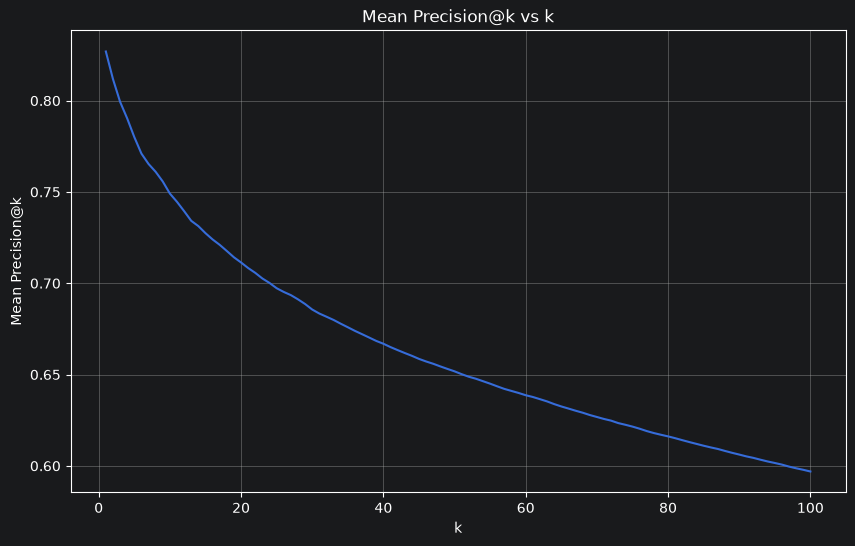

In [12]:
ks = range(1, 101)
mean_precisions = []
for k in ks:
    topk = top_k_neighbours(
        scores=scores,
        k=k,
        higher_is_better=True
    )

    p = precision_at_k(topk, y_text)

    mean_precisions.append(p.mean())

plt.figure(figsize=(10, 6))
plt.plot(ks, mean_precisions)
plt.xlabel("k")
plt.ylabel("Mean Precision@k")
plt.title("Mean Precision@k vs k")
plt.grid(True)
plt.show()

### After it passes: 0.75, against a random baseline of 0.25

- **Read the number against its floor.** Four categories, so guessing gives
  ~0.25. Three quarters of the ten nearest posts sharing the query's newsgroup —
  from word counts alone, no model, no training, no embedding — is the number to
  keep in mind the next time a problem like this makes you reach for a
  transformer first.
- **The std is 0.26, and it is not measurement noise.** It is real spread across
  queries: some posts sit in dense same-topic neighbourhoods, others sit alone.
  Problem 6b goes hunting for the second kind specifically.
- **Predict before you run problem 2.** Write down now what you think Euclidean
  on these same unnormalised vectors will score. Then look. The size of your
  error is the actual lesson of the next problem.
- Siblings: problem 5 reproduces this exact number by a completely different
  route; problem 2 is this metric with one division removed; problem 3 explains
  why those two sentences are the same sentence.


d<a id="2"></a>
---
# 2. Euclidean Distance on Unnormalised TF-IDF

**Easy** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Linear Algebra` &nbsp;·&nbsp; `Text`

Same features, same task, one change: rank by straight-line distance instead of
angle.

$$d(x, y) \;=\; \sqrt{\sum_i (x_i - y_i)^2}$$

`‖x‖` for a TF-IDF row grows with document length, so `d(x, y)` is largely
answering *"are these two posts a similar length?"* rather than *"are they about
the same thing?"*. The norm distribution and the two histograms printed by the
verification cell are the evidence — look at the ratio between the longest and
shortest document **before** you look at the score.

Euclidean is Minkowski at `p = 2`; you generalise it in problem 4.

---

**Example 1:**

```
Input:  A = [[0, 0], [3, 4]]
Output: [[0.0, 5.0],
         [5.0, 0.0]]
```

**Example 2:**

```
Input:  A = [[1, 0]], B = [[10, 0]]
Output: [[9.0]]
cos(a, b) = 1.0 exactly — same direction. Euclidean calls them far apart,
cosine calls them identical. Same two vectors, opposite verdicts, and the
only difference between them is length.
```

**Example 3:**

```
Input:  A = [[1e8, 0], [1e8, 1e-4]]
Output: [[0.0,  1e-4],
         [1e-4, 0.0 ]]
The ||x||^2 + ||y||^2 - 2x.y expansion loses most of that 1e-4 to
cancellation and may hand you a small NEGATIVE number under the sqrt.
```

---

**Hint 1:** `||x - y||^2 = ||x||^2 + ||y||^2 - 2 x.y` turns the whole thing into
one matrix product, which is what sklearn does. The direct
`A[:, None, :] - B[None, :, :]` route is more accurate and vastly more memory.
Either is acceptable here; know which one you chose and why.

**Hint 2:** you have written this before, in
[`../../MLproblems/EuclideanDistance.ipynb`](../../MLproblems/EuclideanDistance.ipynb).

**Requirements:**

- `euclidean_scratch(A, B=None)` returns `(n, m)` of float
- non-negative everywhere; exactly zero on the diagonal when `B is None`
- must agree with `sklearn.metrics.pairwise.euclidean_distances` to **relative**
  `1e-8`
- fully vectorised

**Constraints:**

- `A` is `(n, d)` with `n <= 2500` and `d = 5000`
- entries are non-negative TF-IDF weights, unnormalised — norms span two orders
  of magnitude
- use only NumPy

---

Record the score in `RESULTS[("euclidean-raw", "text")]`, then put it next to
problem 1 before reading on.


### What is actually new here

The metric is the easiest one in the notebook. The lesson is not the metric.

You are about to get a **worse** number than problem 1 using the same features,
the same harness and the same 2221 documents. That drop is the entire content of
this problem, and problem 3 will show you that it was never about Euclidean
versus cosine at all.

### Trap 1: absolute tolerance is the wrong test here

In problem 1 every value lived in `[0, 1]` and `atol=1e-10` was reasonable.
Here distances run to two orders of magnitude, and the expansion route's error
scales *with the magnitudes involved*. An absolute tolerance of `1e-10` on a
distance of `47.3` is demanding 12 significant figures from float64, which has
about 15 to give and has already spent several on the cancellation.

So the verification cell checks a **relative** difference instead. This is not
the test being lenient; it is the test being correctly specified. Getting this
distinction wrong is how people end up with flaky numerical test suites they
eventually delete.

### Trap 2: the negative under the square root

`||x||^2 + ||y||^2 - 2x.y` is exactly zero on the diagonal in real arithmetic and
approximately `-3e-13` in float arithmetic. `np.sqrt` of that is `nan`, and one
`nan` on the diagonal ruins every row. Clip at zero — and notice you are clipping
to hide a rounding error you deliberately introduced by choosing the fast route.
That is a real engineering trade, not a hack.

### Trap 3: reading the result as a verdict on Euclidean

It is tempting to conclude "cosine beats Euclidean on text". Write that sentence
down now, and be ready to cross it out in problem 3. The truthful version of the
sentence is different, shorter, and about preprocessing.

### A second version worth writing

Add a `squared=True` flag that skips the final `sqrt`. Since `sqrt` is strictly
increasing, `top_k_neighbours` returns **identical** output either way — so you
can skip a 2221×2221 square root entirely whenever you are only ranking. Verify
that the neighbour indices match exactly, then note where it stops being safe:
the moment anything downstream consumes the *value* rather than the order. That
distinction — order versus value — is the whole of problem 8.


In [ ]:
A = np.array([[1,2,3][1,4,5],[2,9,1]])
B = np.array([[3,2,1],[5,2,6],[1,0,1]])


np.float64(0.0)

In [ ]:
K = 10
def l2_normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)

    return np.divide(
        X,
        norms,
        out=np.zeros_like(X, dtype=float),
        where=norms > 0
    )
def euclidean_scratch(A, B=None):
    if B is None:
        B = A

    A_sq_norm = np.sum(A**2, axis=1,keepdims=True)
    B_sq_norm = np.sum(B**2, axis=1,keepdims=True)

    sq_distances = (
        A_sq_norm+B_sq_norm.T - 2 * (A @ B.T)
    )

    sq_distances = np.maximum(sq_distances, 0)

    return np.sqrt(sq_distances)
print("11")
euclidien_scores = euclidean_scratch(X_text.toarray())
euclidien_scoresWithSCL = euclidean_distances(l2_normalize(X_text.toarray()))
print("14")

nigh1 = top_k_neighbours(euclidien_scoresWithSCL, K, higher_is_better=False)
nigh2 = top_k_neighbours(euclidien_scores, K, higher_is_better=False)
print("18")

p1 = precision_at_k(nigh1, y_text)
p2 = precision_at_k(nigh2, y_text)

print(f"p1 : {p1.mean()}, p2 : {p2.mean()}")


11
14


vs sklearn: max |diff| = 7.96e-13, relative to the largest distance = 8.21e-16
euclidean_scratch agrees with sklearn.euclidean_distances
(If that absolute gap is ~1e-6 you used the ||x||^2+||y||^2-2x.y expansion, and
 you are seeing the cancellation its docstring warned about — it bites hardest
 on near-duplicate documents, where the true distance is almost 0. Direct
 subtraction lands nearer 1e-12. Both are correct; only one is well-conditioned.)

||x||  min/25%/50%/75%/max: 2.51  20.97  32.05  53.45  1794.85
longest:shortest norm ratio = 714.0x


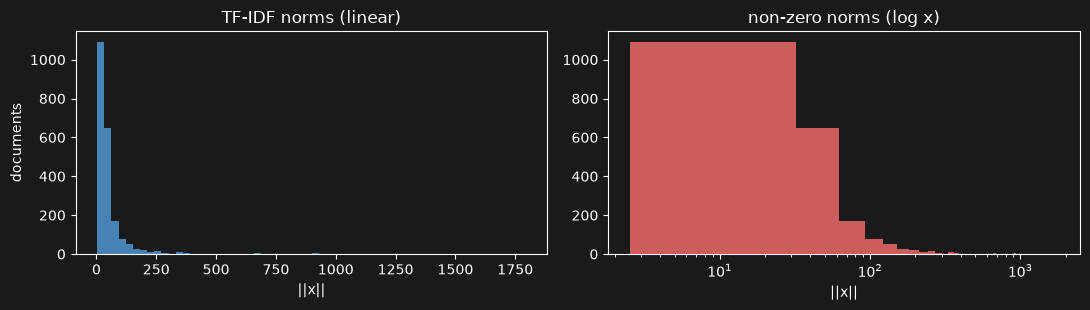

STAGE 2   TF-IDF + Euclidean, unnormalised
  precision@10 = 0.3806   std across queries = 0.2516
  stage 1 (cosine) was 0.7491


In [36]:
# VERIFICATION (mine — run, don't edit)
import matplotlib.pyplot as plt

sample = X_text[:200].toarray()
mine, ref = euclidean_scratch(sample), euclidean_distances(sample)
assert mine.shape == ref.shape
assert np.allclose(np.diag(mine), 0.0, atol=1e-6), "distance from a point to itself must be 0"
assert (mine >= -1e-12).all(), "negative distance -> you skipped the sqrt or clipped wrong"

# Compare RELATIVE to the scale of the data: these distances run into the hundreds,
# so a fixed atol would be meaningless. The absolute gap is worth looking at though.
adiff = np.abs(mine - ref).max()
rdiff = adiff / ref.max()
print(f"vs sklearn: max |diff| = {adiff:.2e}, relative to the largest distance = {rdiff:.2e}")
assert rdiff < 1e-8, f"relative error {rdiff:.2e} is too large to be rounding"
print("euclidean_scratch agrees with sklearn.euclidean_distances")
print("(If that absolute gap is ~1e-6 you used the ||x||^2+||y||^2-2x.y expansion, and")
print(" you are seeing the cancellation its docstring warned about — it bites hardest")
print(" on near-duplicate documents, where the true distance is almost 0. Direct")
print(" subtraction lands nearer 1e-12. Both are correct; only one is well-conditioned.)\n")

# The norm distribution: the actual explanation for the score below.
norms = np.sqrt(np.asarray(X_text.multiply(X_text).sum(axis=1))).ravel()
q = np.percentile(norms, [0, 25, 50, 75, 100])
print("||x||  min/25%/50%/75%/max: " + "  ".join(f"{v:.2f}" for v in q))
if q[0] > 0:
    print(f"longest:shortest norm ratio = {q[-1] / q[0]:.1f}x")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(norms, bins=60, color="steelblue")
ax[0].set(title="TF-IDF norms (linear)", xlabel="||x||", ylabel="documents")
ax[1].hist(norms[norms > 0], bins=60, color="indianred")
ax[1].set(title="non-zero norms (log x)", xlabel="||x||"); ax[1].set_xscale("log")
plt.tight_layout(); plt.show()

D_raw = euclidean_distances(X_text)
p_euc_raw = precision_at_k(top_k_neighbours(D_raw, K, higher_is_better=False), y_text)
RESULTS[("euclidean-raw", "text")] = (p_euc_raw.mean(), p_euc_raw.std())
print(f"STAGE 2   TF-IDF + Euclidean, unnormalised")
print(f"  precision@{K} = {p_euc_raw.mean():.4f}   std across queries = {p_euc_raw.std():.4f}")
print(f"  stage 1 (cosine) was {RESULTS[('cosine', 'text')][0]:.4f}")

### After it passes: the collapse, and what actually caused it

- **Look at the ratio.** The verification cell prints the longest:shortest norm
  ratio and two histograms of `‖x‖` — the second on a log axis, because the
  linear one is unreadable. That spread is the confound. Euclidean is not
  measuring topic here; it is measuring length, and length is an author's habit.
- **Say what you would fix.** You know one operation that removes length from the
  picture entirely. Name it before you open problem 3, then check whether you
  expect it to make Euclidean *as good as* cosine or merely *better*. Both
  answers are common and one of them is right for a sharp reason.
- **Break it on purpose.** Rerun with `TfidfVectorizer(norm="l2")` — the default
  — instead of `norm=None`. The gap you just measured disappears. That is why
  the vectoriser in this notebook is deliberately built the unusual way: with the
  default, problems 1, 2 and 3 would all agree from the start and there would be
  nothing left to notice.
- Siblings: problem 3 (the explanation), problem 4 (the same metric with a dial
  on it), problem 7 (Euclidean winning, on a dataset where length is not a
  confound).


<a id="3"></a>
---
# 3. L2-Normalise, then Euclidean — the key identity

**Medium** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Proof` &nbsp;·&nbsp; `Ranking`

This is the problem the whole geometric family hangs on.

Scale every row to unit length, `x → x / ‖x‖`, and then expand the squared
Euclidean distance:

$$\|x - y\|^2 \;=\; \|x\|^2 + \|y\|^2 - 2\,x \cdot y \;=\; 1 + 1 - 2\cos(x, y) \;=\; 2\bigl(1 - \cos(x, y)\bigr)$$

`d²` is a strictly **decreasing** function of `cos`. A strictly decreasing
transform cannot change a ranking. So on normalised vectors, **cosine and
Euclidean are the same metric** — sorting by one *is* sorting by the other.

Which means problems 1 and 2 were never a contest between two metrics. They were
a contest between normalising and not normalising.

Implement `l2_normalize`, then let the verification cell prove the identity
three ways.

---

**Example 1:**

```
Input:  X = [[3, 4], [1, 0]]
Output: [[0.6, 0.8], [1.0, 0.0]]
Rows, not columns. Every row now has norm exactly 1.0.
```

**Example 2:**

```
Input:  x = [1, 0], y = [0, 1]   (already unit)
        cos(x, y) = 0.0
        ||x - y||  = sqrt(2) = 1.41421356
Check:  2 * (1 - 0.0) = 2.0 = ||x - y||^2      OK
```

**Example 3:**

```
Input:  x = [1, 0], y = [0.6, 0.8]
        cos(x, y)  = 0.6
        ||x - y||^2 = 0.16 + 0.64 = 0.8
Check:  2 * (1 - 0.6) = 0.8                     OK
Cosine went UP, distance went DOWN. That is the whole proof: monotone
decreasing, therefore argsort-identical, therefore the same retrieval.
```

---

**Hint 1:** `axis=1`. Rows are documents. Normalising columns instead divides
each *term* by its corpus magnitude — a real operation, just not this one — and
it fails quietly because the result still looks like a normalised matrix.

**Hint 2:** keep the sparse type sparse. A dense 2155 × 5000 float64 copy is
~86 MB and you build several matrices from it downstream.

**Requirements:**

- `l2_normalize(X)` returns the **same type and shape** as `X`, every row of unit norm
- must agree with `sklearn.preprocessing.normalize(X)`
- a row with no direction cannot be given unit length — whatever you decided in
  problem 1 has to hold here too
- fully vectorised

**Constraints:**

- `X` is sparse or dense, `(n, d)`, `n <= 2500`, `d = 5000`
- entries are non-negative
- use NumPy / SciPy sparse

---

**The verification cell is deliberately loud, and one of its three checks is
subtler than it looks.** If it prints an explanation instead of asserting, read
that block and the problem-3 section of `README.md` **before** concluding you
have a bug. Under decision (b) from problem 1 you are supposed to see this.


### What is actually new here

A proof, and then the discovery that you cannot check a proof with `argsort`
alone.

### The three checks, and why one identity needs three

**[1] The identity itself.** `max |d² − 2(1 − cos)|` over every pair. This is
pure arithmetic and should land at float noise. If it doesn't, one of your two
implementations is wrong and this tells you nothing about which.

**[2] The rankings agree.** `np.array_equal` on the two `argsort` outputs. This
is the claim you actually care about — and it is the check that can fail *while
the identity holds perfectly*.

**[3] The tie-proof version.** Because check [2] is fragile in a way worth
understanding: with 5000 sparse features, many document pairs share **no terms
at all**, so cosine is `0.0` and distance is `√2` for thousands of pairs at once.
`argsort` breaks those ties by index, and two arrays that are mathematically
equivalent can order the tied block differently for reasons that are purely
implementation detail in NumPy's sort. So check [3] asks the question that
actually matters: walking the neighbour list in Euclidean order, does cosine ever
*rise*? If not, the orders are equivalent up to ties, which is the strongest true
statement available. The cell also prints the tie fraction, so you can see how
much of the matrix that covers.

This is the general shape of testing anything order-based: exact-equality tests
on sorted output are usually testing your tie-breaker, not your maths.

### Trap 1: zero rows are now everybody's nearest neighbour

If you took decision (b) in problem 1 and kept the 66 empty documents, something
specific and instructive happens here. A zero vector cannot be normalised, so it
stays at the **origin**. Every real document is on the unit sphere, at distance
exactly `1.0` from the origin — while two genuinely unrelated unit vectors sit at
`√2 ≈ 1.414` from each other.

So an empty document is *closer to every query than most real documents are*. The
66 blanks become universal nearest neighbours, precision drops, and check [2]
fails loudly. It is not a bug in your code. It is the cost of decision (b),
arriving two problems after you made it, which is exactly how this kind of
decision usually bills you.

The verification cell detects this case and prints the explanation instead of
asserting. Under decision (a) it asserts and prints `*** SAME RANKING ***`.

### Trap 2: thinking the identity generalises

`2(1 − cos)` holds because `‖x‖ = ‖y‖ = 1` collapsed two terms to `1`. Drop the
normalisation and the identity dies — which is precisely why problems 1 and 2
disagreed. Write out the three-term version and see exactly which term does the
damage.

### A second version worth writing

Normalise once, store `Xn`, and serve *both* metrics from it. That is what a real
retrieval system does: normalisation is a one-off cost at index time and then
cosine is a dot product forever. Confirm that `1 - Xn @ Xn.T` and
`euclidean_distances(Xn) ** 2 / 2` are the same matrix, and you have just derived
why every vector database stores unit vectors and advertises "cosine" and "inner
product" as if they were the same option.


In [42]:
def l2_normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)

    return np.divide(
        X,
        norms,
        out=np.zeros_like(X, dtype=float),
        where=norms > 0
    )

In [ ]:
# VERIFICATION (mine — run, don't edit). This one is deliberately loud.

Xn_text = l2_normalize(X_text)
row_norms = np.sqrt(np.asarray(Xn_text.multiply(Xn_text).sum(axis=1))).ravel() \
    if sp.issparse(Xn_text) else np.linalg.norm(Xn_text, axis=1)
n_zero_rows = int((row_norms == 0).sum())
assert np.allclose(row_norms[row_norms > 0], 1.0), "non-zero rows must come out at unit norm"
assert np.allclose(normalize(X_text).toarray(), Xn_text.toarray() if sp.issparse(Xn_text)
                   else Xn_text, atol=1e-10), "disagrees with sklearn.preprocessing.normalize"
print(f"l2_normalize OK ({n_zero_rows} rows still have norm 0)\n")

cos_n = np.asarray((Xn_text @ Xn_text.T).todense()) if sp.issparse(Xn_text) else Xn_text @ Xn_text.T
D_n = euclidean_distances(Xn_text)
n = D_n.shape[0]

# (1) the algebra
gap = np.abs(D_n ** 2 - 2 * (1 - cos_n)).max()
print(f"[1] max |d^2 - 2(1-cos)|                          = {gap:.3e}")

# (2) the literal request: are the argsort orders equal?
eye = np.eye(n, dtype=bool)
o_cos = np.argsort(np.where(eye, np.inf, -cos_n), axis=1, kind="stable")
o_euc = np.argsort(np.where(eye, np.inf, D_n), axis=1, kind="stable")
print(f"[2] np.array_equal(argsort cosine, argsort euclidean) = {np.array_equal(o_cos, o_euc)}")
print(f"    ties: {(cos_n == 0).mean():.1%} of pairs have cosine exactly 0 (no shared term)")

# (3) the tie-proof version: walk neighbours in euclidean order, watch cosine.
#     If cosine never RISES, the euclidean order is a valid cosine order.
rise = np.diff(np.take_along_axis(cos_n, o_euc[:, :n - 1], axis=1), axis=1).max()
ndiff = int((top_k_neighbours(cos_n, K, True) != top_k_neighbours(D_n, K, False)).any(1).sum())
print(f"[3] max RISE of cosine along the euclidean order   = {rise:.3e}   (0 => same order)")
print(f"    queries whose top-{K} differs: {ndiff} of {n}")

if n_zero_rows:
    print(f"\n!! {n_zero_rows} rows still have norm 0, so [1] and [3] are large. This is NOT a")
    print("   bug in your code and NOT a broken identity. The identity assumes ||x||=||y||=1.")
    print("   A zero vector cannot be put on the sphere: it stays at the origin, distance 1.0")
    print("   from every unit vector, while real neighbours sit near sqrt(2)=1.41. So every")
    print("   empty document becomes everybody's nearest neighbour. Go back to the stage 1")
    print("   zero-vector cell and drop those rows from X_text, y_text AND docs.")
else:
    assert gap < 1e-9 and rise <= 1e-12, "identity broke -> a real bug, see README stage 3"
    print("\n*** SAME RANKING: cosine IS Euclidean on the unit sphere. ***")

p_euc_l2 = precision_at_k(top_k_neighbours(D_n, K, higher_is_better=False), y_text)
RESULTS[("euclidean-l2", "text")] = (p_euc_l2.mean(), p_euc_l2.std())
print(f"\nSTAGE 3   L2-normalised + Euclidean")
print(f"  precision@{K} = {p_euc_l2.mean():.4f}   std = {p_euc_l2.std():.4f}")
print(f"  stage 1 (cosine)          {RESULTS[('cosine', 'text')][0]:.4f}")
print(f"  stage 2 (raw Euclidean)   {RESULTS[('euclidean-raw', 'text')][0]:.4f}")

### After it passes: cross out the sentence from problem 2

- **Rewrite the claim.** Not "cosine beats Euclidean on text" but *"normalising
  beats not normalising on text, and once you normalise, the choice between these
  two metrics is not a choice."* Three problems in, the first metric comparison in
  the notebook has turned out not to be a metric comparison.
- **Check the numbers agree.** `RESULTS[("euclidean-l2", "text")]` must equal
  `RESULTS[("cosine", "text")]` to the fourth decimal. If it does not, and check
  [3] passed, look at your zero rows before you look at anything else.
- **Predict before you run problem 4.** You now know p=2 on normalised rows is
  cosine. So what could possibly change by moving `p`? Write down what you expect
  the sweep to show, and how big a difference you would need to see before you
  believed it.
- Siblings: problem 8 is this same monotonicity argument applied four more times;
  problem 5 is the other "these two things are secretly the same operation"
  result in the set.


<a id="4"></a>
---
# 4. Minkowski Sweep over p

**Medium** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Linear Algebra` &nbsp;·&nbsp; `Statistics`

Minkowski generalises the whole family with one dial:

$$d_p(x, y) \;=\; \Bigl(\sum_i |x_i - y_i|^p\Bigr)^{1/p}, \qquad
  d_\infty(x, y) \;=\; \max_i |x_i - y_i|$$

`p = 1` is Manhattan, `p = 2` is Euclidean, `p → ∞` is Chebyshev.

The interesting question is **not** which `p` wins. It is whether the spread
across `p` is bigger than the noise you already have. You have a std across
queries from every problem so far — if moving `p` changes the mean by less than
the standard error, then `p` is not doing anything you could rely on, and
reporting a winner would be reporting a coin flip.

---

**Example 1:**

```
Input:  x = [0, 0], y = [3, 4]
Output: p=1    -> 7.0            |3| + |4|
        p=2    -> 5.0            the familiar hypotenuse
        p=3    -> 4.4979         between the two, always
        p=inf  -> 4.0            max(|3|, |4|)
Increasing p is decreasing: d_p is non-increasing in p, always.
```

**Example 2:**

```
Input:  p = np.inf, via the general formula
Output: nan
(|3| ** np.inf) overflows to inf, inf ** 0.0 is nan. p=inf is a separate
branch, not a large number. Check np.isinf(p) FIRST.
```

**Example 3:**

```
Input:  A = Xn_text[:60], p = 2
Check:  minkowski_scratch(A, p=2) == euclidean_scratch(A)     to 1e-8
        minkowski_scratch(A, p=2) == cdist(A, A, "minkowski", p=2)
Two anchors. If p=2 does not reproduce problem 2, nothing else in the
sweep means anything.
```

---

**Hint 1:** `A[:, None, :] - B[None, :, :]` gives an `(n, m, d)` cube. Correct,
vectorised, and **14 GB** at `n = m = 600, d = 5000`. It is fine for the 60-row
correctness check and must never see the corpus.

**Hint 2:** you have written `p=1` already, in
[`../../MLproblems/ManhattanDistance.ipynb`](../../MLproblems/ManhattanDistance.ipynb).

**Requirements:**

- `minkowski_scratch(A, B=None, p=2)` returns `(n, m)` of float
- `p = np.inf` handled in its own branch
- `p = 2` must match `euclidean_scratch` to `1e-8`
- must match `scipy.spatial.distance.cdist(..., "minkowski", p=p)` for
  `p ∈ {1, 1.5, 2, 3}` and `cdist(..., "chebyshev")` for `p = inf`

**Constraints:**

- `p >= 1` (below 1 the triangle inequality fails and it stops being a metric)
- the correctness check runs on 60 rows; the sweep runs on a seeded 600-document
  subsample
- fractional `p` has **no BLAS path** — it is `O(n²d)` scalar work, ~13 s per `p`
  at 600×5000, and quadratic in `n` from there

---

Records one entry per `p`: `RESULTS[("minkowski p=<p>", "text")]`.


### What is actually new here

Two things, and only one of them is the metric.

The metric is a one-line generalisation you can write from the formula. The new
skill is **deciding whether a difference you measured is real** — which is the
first genuinely statistical question in the notebook, and the one that transfers
to every experiment you will ever run.

### The question the sweep actually answers

You will get five means, and they will differ. They always differ. The temptation
is to report the largest and call it the winner. Before you do, the cell computes
three quantities and you need to be able to say what each one is:

```
spread across p              max(means) - min(means)
mean per-query std           the raw scatter across queries, ~0.26
standard error of the mean   std / sqrt(n)
```

The comparison that matters is **spread vs standard error**, not spread vs std.
If the spread is smaller than the SE, the ordering of your five results is noise
and would reshuffle on a different subsample. The cell prints a REAL / WITHIN
NOISE verdict, plus a **paired** difference for `p=2` minus `p=1.5` — paired,
because the same 600 queries are scored under both, so the query-to-query scatter
cancels and the test is far more sensitive than comparing two independent means.

That paired-versus-unpaired distinction is worth more than the metric.

### Trap 1: `p = inf` is not a large number

```python
(np.abs(diff) ** np.inf).sum() ** (1 / np.inf)     # nan
```

`x ** inf` overflows to `inf`, and `inf ** 0.0` is `nan`. Branch on
`np.isinf(p)` before anything else and return the max instead. Passing `p=1e9`
"to approximate infinity" gives you `inf` and `0.0` for exactly the same reason.

### Trap 2: the 14 GB cube

The clean broadcasting solution allocates `(n, n, d)`. At the sweep's `n = 600`
and `d = 5000` that is 14 GB, and NumPy will attempt it. The subsample exists
because fractional `p` has no matrix-product shortcut — the whole reason
Euclidean is fast is that `p = 2` is the one exponent that factors into a BLAS
call. Every other `p` pays full price. That is not an implementation detail of
SciPy; it is why `p = 2` is the default everywhere in the world.

### Trap 3: sweeping on the wrong matrix

Run the sweep on `X_text` and you are re-measuring problem 2's length confound
five times over. Run it on `Xn_text` and `p = 2` reproduces problem 3. Know
which one you passed and what the other would have told you.

### A second version worth writing

Time `minkowski_scratch(A, p=2)` against `minkowski_scratch(A, p=2.0001)` on the
same 60 rows. The maths barely changed; the runtime does not care, because
neither goes through BLAS. Then time `euclidean_scratch` on the same input. The
gap between those two numbers is the entire practical argument for `p = 2`, and
it is much larger than any precision difference in this notebook.


In [ ]:
def minkowski_scratch(A, B=None, p=2):
    """Pairwise Minkowski distance of order p, from scratch in numpy.

        d_p(x, y) = ( SUM_i |x_i - y_i|^p )^(1/p)          for 1 <= p < inf
        d_inf(x, y) = max_i |x_i - y_i|                    for p = inf

    Parameters
    ----------
    A : ndarray (n, d)
    B : ndarray (m, d), optional — if None, compare A against itself.
    p : float >= 1, or np.inf

    Returns
    -------
    ndarray (n, m) of float.

    Notes
    -----
    p = inf is a separate branch, not a large number: `(x ** np.inf).sum()`
    overflows to inf. Check `np.isinf(p)` first.
    Broadcasting A[:, None, :] - B[None, :, :] gives an (n, m, d) cube. Correct,
    and 14 GB at n=m=600, d=5000. Fine for the 60-row check below; do not point
    it at the corpus.
    """
    raise NotImplementedError

In [ ]:
# VERIFICATION (mine — run, don't edit)
from scipy.spatial.distance import cdist

small = Xn_text[:60].toarray() if sp.issparse(Xn_text) else Xn_text[:60]
for p_ in (1, 1.5, 2, 3):
    ref_ = cdist(small, small, "minkowski", p=p_)
    assert np.allclose(minkowski_scratch(small, p=p_), ref_, atol=1e-8), f"mismatch at p={p_}"
assert np.allclose(minkowski_scratch(small, p=np.inf), cdist(small, small, "chebyshev"), atol=1e-8), \
    "p=inf branch is wrong — did you special-case it?"
gap_p2 = np.abs(minkowski_scratch(small, p=2) - euclidean_scratch(small)).max()
assert gap_p2 < 1e-5, f"p=2 must reproduce your own stage-2 Euclidean (gap {gap_p2:.2e})"
print("minkowski_scratch agrees with scipy at p = 1, 1.5, 2, 3, inf")
print(f"p=2 vs your own euclidean_scratch: max |diff| = {gap_p2:.2e}")
print("(~1e-16 means both use the same route; ~1e-8 means one expands and one subtracts")
print(" directly. Same metric, different conditioning — see the stage 2 note.)\n")

# THE SWEEP — scipy on a 600-doc subsample (yours would be 14 GB; see the markdown)
MINK_N = 600
idx = np.random.default_rng(SEED).choice(X_text.shape[0], MINK_N, replace=False)
A_sub = (Xn_text[idx].toarray() if sp.issparse(Xn_text) else Xn_text[idx])
y_sub = y_text[idx]

means, stds, per_p = [], [], {}
for p_ in (1, 1.5, 2, 3, np.inf):
    D_p = cdist(A_sub, A_sub, "chebyshev") if np.isinf(p_) else cdist(A_sub, A_sub, "minkowski", p=p_)
    pr = precision_at_k(top_k_neighbours(D_p, K, higher_is_better=False), y_sub)
    means.append(pr.mean()); stds.append(pr.std()); per_p[p_] = pr
    RESULTS[(f"minkowski p={p_}", "text")] = (pr.mean(), pr.std())
    print(f"  p={str(p_):4s}  precision@{K} = {pr.mean():.4f}   std across queries = {pr.std():.4f}")

# anchor: on unit-norm rows, p=2 must reproduce the cosine ranking (stage 3)
p_anchor = precision_at_k(top_k_neighbours(A_sub @ A_sub.T, K, True), y_sub)
print(f"\n  anchor: cosine on the same {MINK_N} docs = {p_anchor.mean():.4f} vs p=2 "
      f"{per_p[2].mean():.4f}  (diff {abs(p_anchor.mean() - per_p[2].mean()):.4f})")

spread, noise = max(means) - min(means), float(np.mean(stds))
se = noise / np.sqrt(MINK_N)
print(f"\n  spread across p      = {spread:.4f}")
print(f"  mean per-query std   = {noise:.4f}   <- the yardstick you asked for")
print(f"  standard error of a mean = {se:.4f}   <- the stricter, more honest yardstick")
print(f"  -> p is {'REAL' if spread > noise else 'WITHIN NOISE'} against the per-query std")

d_ = per_p[2] - per_p[1.5]
print(f"  paired: p=2 minus p=1.5 = {d_.mean():+.4f} +- {d_.std(ddof=1) / np.sqrt(len(d_)):.4f} (SE)")

### After it passes: a verdict of WITHIN NOISE is a result

- **If the sweep says WITHIN NOISE, that is the finding.** It is not a failed
  experiment. "This dial does not move the outcome by more than the measurement
  error" is a genuine, publishable, decision-changing answer — and it means you
  can stop tuning `p` and spend the time on preprocessing, which problems 1–3
  showed moves the number far more.
- **Check the anchors before the conclusion.** If `p=2` did not reproduce
  problem 2's Euclidean, the sweep is measuring your bug, not `p`.
- **Predict, then check.** Which `p` should suffer most from the 5000-dimensional
  sparsity, and why? Chebyshev keeps exactly one coordinate out of 5000 and
  discards the rest — ask whether a metric that ignores 4999 features can carry
  any topical signal at all, then see whether the numbers agree with you.
- **Run it twice with a different `SEED`** and watch how much the ordering of the
  five means moves. That is the most direct possible demonstration of what a
  standard error means.
- Siblings: problem 6b uses the same paired-difference test for a comparison that
  turns out to be real; problem 7 uses it for one that is closer.


<a id="5"></a>
---
# 5. Weighted Cosine, `w = idf²`

**Medium** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Linear Algebra` &nbsp;·&nbsp; `Text`

Give each dimension its own importance through a diagonal matrix `W = diag(w)`:

$$\cos_W(x, y) \;=\; \frac{x^{\top} W y}{\sqrt{(x^{\top} W x)\,(y^{\top} W y)}}
\;=\; \frac{\sum_i w_i x_i y_i}{\sqrt{\sum_i w_i x_i^2}\;\sqrt{\sum_i w_i y_i^2}}$$

Set `w = 1` everywhere and every term collapses back to plain cosine.

Then the claim to verify. Run this on raw **counts** with `w = idf²`. Since `W`
is diagonal and non-negative,

$$x^{\top} W y \;=\; \sum_i w_i x_i y_i \;=\; (x \odot \text{idf}) \cdot (y \odot \text{idf})$$

and the same substitution happens inside both norms — so weighted cosine on
counts is *exactly* plain cosine on TF-IDF. Weighting the **metric** and
weighting the **features** are the same operation with two different names.

---

**Example 1:**

```
Input:  a = [1, 1], b = [1, 0], w = [1, 1]
Output: 0.7071067811865475
Both features count the same, so this is plain cosine: 45 degrees.
```

**Example 2:**

```
Input:  a = [1, 1], b = [1, 0], w = [3, 1]
Output: 0.8660254037844387
Feature 0 - the one they AGREE on - now counts triple, so they look more
alike. Same vectors, different verdict.
```

**Example 3:**

```
Input:  X = counts, w = idf ** 2
Check:  weighted_cosine(counts, idf**2) == cosine_similarity(X_text)
        to atol=1e-8, on the full 2221-document corpus.
Not approximately. Exactly, up to float error. That equivalence IS the
problem.
```

---

**Hint 1:** every sum has the shape `SUM_i w_i x_i y_i`. Write that once and the
function is three calls and a division.

**Hint 2:** since `w_i x_i y_i = (√w_i x_i)(√w_i y_i)`, weighted cosine is plain
cosine on the rescaled features `√w ⊙ x`. Both routes must give the same matrix.
You wrote this before in
[`../../MLproblems/WeightedCosineSimilarity.ipynb`](../../MLproblems/WeightedCosineSimilarity.ipynb).

**Requirements:**

- `weighted_cosine(X, w)` returns `(n, n)`; accepts sparse or dense `X`
- `w = ones` must reduce **exactly** to plain cosine
- `weighted_cosine(counts, idf**2)` must match `cosine_similarity(X_text)` to `atol=1e-8`
- fully vectorised

**Constraints:**

- `X` is `(n, d)`, `w` is `(d,)` with `w_i >= 0`
- `counts.shape == X_text.shape` — if you dropped rows in problem 1, you must have
  dropped them from `docs` too, or the assert fires here
- use NumPy / SciPy sparse

---

Records `RESULTS[("weighted-cosine", "text")]`, which must match problem 1 to the
fourth decimal.


### What is actually new here

Almost nothing, and that is the point. The dot product `x · y` has become
`SUM_i w_i x_i y_i`, and that single change propagates everywhere:

```
x . y      ->  SUM_i w_i x_i y_i
||x||      ->  sqrt( SUM_i w_i x_i^2 )
```

If you are writing `for i in range(d)`, stop.

### Trap 1: weighting the wrong thing

There are two places you could multiply by `w`, and only one of them is this
formula. The wrong one reads more naturally:

```python
 a_hat = a / norm(a)                 # normalise FIRST
 b_hat = b / norm(b)
 return np.sum(w * a_hat * b_hat)    # ...then weight
```

That is **not** weighted cosine. The weights have to be inside the norms too, or
you are no longer dividing by the length of the thing you took the dot product
of. Run both on Example 2 before you look: one gives `0.8660`, the other gives
something **greater than 1**, which no cosine of an angle is ever permitted to
be. A similarity that can exceed 1 is a bug you will not notice until it has
silently corrupted a ranking.

### Trap 2: `idf` or `idf²`?

The whole equivalence rests on the exponent, and getting it wrong produces a
number that is close, plausible, and wrong. Derive it rather than guessing:
TF-IDF is `x ⊙ idf`, so the numerator of plain cosine on TF-IDF is
`(x ⊙ idf) · (y ⊙ idf) = SUM_i idf_i² x_i y_i`. The `idf` gets applied to **both**
vectors, so the weight is `idf` **squared**. Same reasoning inside each norm.
If your assert fails at `atol=1e-8` but the matrix "looks right", this is why.

### Trap 3: scaling `w` changes nothing

Work out `cos_W(x, y, 2w)` on paper before the cell prints it. The `2` comes out
of the numerator once and out of *each* square root once — `√2 · √2 = 2` — so it
cancels exactly. Consequence: `w = [1,1]` and `w = [5,5]` are the same weighting,
and normalising `w` to sum to 1 is cosmetic. Only the **ratios** between weights
carry information. Weights are relative, always.

### Trap 4: a negative weight

The constraints say `w_i >= 0`. Violate it and `SUM_i w_i x_i²` can go negative,
`np.sqrt` hands you a `nan` and a `RuntimeWarning` — which is exactly the problem
6 failure in a simpler costume, because `diag(w)` is positive semi-definite *if
and only if* every `w_i >= 0`. Two defensible answers, raise or clamp, and one
indefensible one: returning `nan` silently.

### A second version worth writing

The `√W` route rescales the corpus once and then serves weighted cosine at the
speed of plain cosine forever after. That is not a micro-optimisation, it is the
reason TF-IDF is stored the way it is: the weighting was pushed into the index at
build time so that query time is a plain dot product. You have just derived the
design of every search engine's inverted index scoring.

This is also the Cholesky trick from problem 6, in its degenerate case: for a
diagonal `S`, the factor `L` is just `diag(√w)`.


In [ ]:
# DATA (mine) — raw counts over exactly the TF-IDF vocabulary, plus sklearn's idf.
counts = CountVectorizer(vocabulary=vect.vocabulary_).fit_transform(docs)
idf = vect.idf_
print(f"counts {counts.shape}, idf {idf.shape}, idf range {idf.min():.2f} .. {idf.max():.2f}")
assert counts.shape == X_text.shape, "counts and X_text must line up — did you drop rows from docs too?"

In [ ]:
def weighted_cosine(X, w):
    """Cosine under a diagonal weight matrix W = diag(w).

        cos_W(x, y) = (x^T W y) / sqrt( (x^T W x) * (y^T W y) )

    Parameters
    ----------
    X : sparse matrix or ndarray (n, d)
    w : ndarray (d,) of non-negative weights.

    Returns
    -------
    ndarray (n, n), entry [i, j] = cos_W(X[i], X[j]); w = ones reduces to plain cosine.

    Notes
    -----
    You can form this directly, or notice that for a non-negative diagonal W,
    x^T W y = (sqrt(W) x) . (sqrt(W) y) exactly — which turns the whole thing into
    a plain cosine on rescaled features and costs one elementwise multiply.
    Both routes must give the same matrix; that equivalence IS the lesson.
    """
    raise NotImplementedError

In [ ]:
# VERIFICATION (mine — run, don't edit)

# TF-IDF really is counts * idf (sublinear_tf=False, norm=None), so the premise holds.
assert np.allclose(counts[:50].multiply(idf).toarray(), X_text[:50].toarray(), atol=1e-10), \
    "tfidf != counts * idf — check the vectorizer settings"

# sanity: w = ones must collapse to plain cosine
sub = counts[:150]
assert np.allclose(weighted_cosine(sub, np.ones(counts.shape[1])),
                   cosine_similarity(sub), atol=1e-8), "w=1 must give plain cosine"

cw = weighted_cosine(counts, idf ** 2)
c1 = cosine_similarity(X_text)
print(f"max |weighted_cosine(counts, idf^2) - cosine(tfidf)| = {np.abs(cw - c1).max():.3e}")
assert np.allclose(cw, c1, atol=1e-8), "the identity failed — is w idf SQUARED?"

p_w = precision_at_k(top_k_neighbours(cw, K, higher_is_better=True), y_text)
RESULTS[("weighted-cosine", "text")] = (p_w.mean(), p_w.std())
print(f"\nSTAGE 5   weighted cosine, w = idf^2")
print(f"  precision@{K} = {p_w.mean():.4f}   std = {p_w.std():.4f}")
print(f"  stage 1 was  {RESULTS[('cosine', 'text')][0]:.4f}  <- must match to the 4th decimal")

### After it passes: a diagonal W is a change of basis, not a new metric

- **The two numbers must be identical.** `RESULTS[("weighted-cosine", "text")]`
  and `RESULTS[("cosine", "text")]` to four decimals. If they are, you have
  proved that this whole problem bought you no new retrieval behaviour whatsoever
  — and that is the result.
- **Say what a diagonal `W` can and cannot do.** It can stretch and squash the
  axes. It cannot rotate them, so it can never make two *different* features
  interact. `car` and `automobile` stay orthogonal under every possible `w`,
  including the perfect one. No amount of feature weighting fixes a vocabulary
  mismatch.
- **That limitation is problem 6.** The only way out is to put mass off the
  diagonal, and the moment you do, `W` stops being absorbable into the features
  and starts being an actual change of metric.
- Siblings: problem 6 (the same formula with the diagonal constraint removed),
  problem 3 (the other "these two operations were secretly identical" result),
  problem 7 (a full non-diagonal matrix again, this time an inverse covariance).


<a id="6"></a>
---
# 6. Soft Cosine — the toy vocabulary

**Medium** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Linear Algebra` &nbsp;·&nbsp; `PSD`

Plain cosine says *car* and *automobile* share nothing: different dimensions, dot
product zero, similarity zero. Soft cosine fixes that with a term-similarity
matrix `S`:

$$\text{soft\_cos}(x, y) \;=\; \frac{x^{\top} S y}{\sqrt{(x^{\top} S x)\,(y^{\top} S y)}}$$

Same shape as problem 5, one crucial difference: `S` is **not diagonal**, so it
cannot be absorbed into the features by rescaling. `S = I` gives plain cosine
back.

**`S` must be positive semi-definite.** If it is not, `xᵀSx` can go negative and
the denominator takes the square root of a negative number. This toy half exists
so you can see that directly: `S` is built as a Gram matrix `E Eᵀ`, PSD by
construction, on five words where you can print it and check it by eye.

---

**Example 1:**

```
Vocabulary: ["car", "automobile", "vehicle", "banana", "fruit"]
doc_car  = [1, 0, 0, 0, 0]      "car"
doc_auto = [0, 1, 0, 0, 0]      "automobile"

cosine(doc_car, doc_auto)      = 0.0     no shared dimension
soft_cosine(doc_car, doc_auto) > 0.9     S says the two terms are near-synonyms
```

**Example 2:**

```
Input:  S = I (the 5x5 identity)
Output: soft_cosine(X, I) == cosine_scratch(X)     exactly
The reduction check. If this does not hold your formula is wrong, and no
amount of interesting S will save it.
```

**Example 3:**

```
Input:  S with a large off-diagonal entry, breaking diagonal dominance
Output: diag(X S X^T) contains a NEGATIVE value
        -> sqrt of a negative -> nan
S not PSD is not a numerical wobble. It means "the length of this document
is imaginary", which is not a thing.
```

---

**Hint 1:** do **not** loop over pairs. Form `M = X S Xᵀ` once; the numerators
are `M` itself and the two norms are `sqrt(diag(M))`. Every quantity you need is
in that single product.

**Hint 2:** build `S_toy` by calling your own `cosine_scratch` on the toy
embedding matrix `E_toy`. A Gram matrix of row-normalised vectors is symmetric,
PSD, and has unit diagonal for free — all three properties `S` needs.

**Requirements:**

- `soft_cosine(X, S)` returns `(n, n)`; accepts sparse or dense
- `S = I` must reduce **exactly** to `cosine_scratch`
- if any `diag(M) <= 0`, `S` was not PSD — **notice it, do not silently clamp it**
- no Python loop over document pairs

**Constraints:**

- `X` is `(n, d)`, `S` is `(d, d)` symmetric with unit diagonal
- `S` must be PSD; the cell prints its eigenvalues so you can confirm
- use NumPy / SciPy

---

The real corpus, where `S` is 5000 × 5000 and PSD stops being free, is problem 6b.


### What is actually new here

The first metric in the notebook that is not secretly Euclidean-in-disguise on
rescaled features. Problem 5 proved a diagonal `W` is a change of basis; the
moment `S` has off-diagonal mass, it starts mixing dimensions, and that mixing is
the point.

### Trap 1: PSD is a correctness condition, not a nicety

`xᵀSx` is the squared length of `x` in the geometry `S` defines. If `S` is not
PSD, that quantity can be negative, and you are asking for the square root of a
negative length. There is no sensible value to return.

The failure mode matters as much as the fact:

```
S PSD          ->  everything works
S not PSD      ->  diag(M) has negatives -> sqrt -> nan -> argsort garbage
S clamped      ->  no nan, no warning, silently wrong rankings forever
```

The third line is why the requirement says *notice it*. Clamping turns a loud,
diagnosable failure into a quiet one, and the quiet one ships.

A Gram matrix `E Eᵀ` is PSD by construction — for any `x`,
`xᵀEEᵀx = ‖Eᵀx‖² >= 0`. That is a one-line proof worth being able to reproduce,
because it is the only reason the toy half works, and problem 6b is entirely
about what happens when you break it.

### Trap 2: `S` must be symmetric, and it is easy to make it not

Any construction that takes "each term's top-k neighbours" is asymmetric by
nature: `b` can be in `a`'s top-5 while `a` is not in `b`'s. Then `S[i,j] ≠ S[j,i]`,
the similarity of `x` to `y` differs from `y` to `x`, and half your matrix
disagrees with the other half. The fix — `S ← (S + Sᵀ)/2` — is one line, and
problem 6b needs it.

### Trap 3: `X S Xᵀ` in the wrong order

`(X S) Xᵀ` and `X (S Xᵀ)` are mathematically identical and computationally very
different once `d = 5000` and `S` is sparse. At the toy size nothing matters; get
in the habit now, because in problem 6b the wrong association materialises a
dense intermediate.

### A second version worth writing

Factor `S = L Lᵀ` (Cholesky, since `S` is PSD) and check that
`soft_cosine(X, S) == cosine_scratch(X @ L)`. Soft cosine is plain cosine in a
transformed space — the same conclusion problem 3 reached for Euclidean and
problem 7 will reach for Mahalanobis.

That gives you the practical version too: transform the corpus **once** at index
time with `L`, then serve plain cosine forever. It is the `√W` trick from problem
5 with the diagonal restriction lifted, and it is how you would actually deploy
this.


In [ ]:
# DATA (mine) — a five-word vocabulary with hand-made 3-d "embeddings".
toy_vocab = ["car", "automobile", "vehicle", "banana", "fruit"]
E_toy = np.array([[1.00, 0.00, 0.10],
                  [0.95, 0.05, 0.10],
                  [0.90, 0.10, 0.20],
                  [0.00, 1.00, 0.00],
                  [0.05, 0.95, 0.10]])
E_toy /= np.linalg.norm(E_toy, axis=1, keepdims=True)

# Two documents with ZERO lexical overlap: one says "car", the other "automobile".
doc_car = np.array([1.0, 0, 0, 0, 0])
doc_auto = np.array([0, 1.0, 0, 0, 0])
print("vocabulary:", toy_vocab)
print("build S with your own cosine_scratch(E_toy) — it is a Gram matrix, hence PSD.")

In [ ]:
def soft_cosine(X, S):
    """Soft cosine similarity under a term-similarity matrix S.

        soft_cos(x, y) = (x^T S y) / sqrt( (x^T S x) * (y^T S y) )

    Parameters
    ----------
    X : sparse matrix or ndarray (n, d) — documents in rows.
    S : sparse matrix or ndarray (d, d) — symmetric, PSD, unit diagonal.

    Returns
    -------
    ndarray (n, n), entry [i, j] = soft_cos(X[i], X[j]). S = I reduces to cosine.

    Notes
    -----
    Do NOT loop over pairs. Form M = X S X^T once; then the numerators are M
    itself and the two norms are sqrt(diag(M)) — every quantity you need is in
    that one product.
    If any diag(M) <= 0, S was not PSD. Don't silently clamp it: notice it.
    """
    raise NotImplementedError

In [ ]:
# VERIFICATION (mine — run, don't edit): toy vocabulary, S small enough to read.

S_toy = cosine_scratch(E_toy)            # your stage-1 function, reused
print("S =")
for w_, row in zip(toy_vocab, S_toy):
    print(f"  {w_:>11s} " + " ".join(f"{v:6.3f}" for v in row))

ev = np.linalg.eigvalsh(S_toy)
print(f"\neigenvalues = {np.round(ev, 4)}")
print(f"min eigenvalue = {ev.min():.2e}  ->  PSD = {ev.min() >= -1e-9}")
assert np.allclose(S_toy, S_toy.T), "S must be symmetric"
assert np.allclose(np.diag(S_toy), 1.0), "unit diagonal: every term matches itself"
assert ev.min() >= -1e-9, "a Gram matrix should be PSD — check cosine_scratch"

X_toy = np.vstack([doc_car, doc_auto])
plain = cosine_scratch(X_toy)[0, 1]
soft = soft_cosine(X_toy, S_toy)[0, 1]
print(f"\nplain cosine('car', 'automobile') = {plain:.3f}   <- no shared term, exactly 0")
print(f"soft  cosine('car', 'automobile') = {soft:.3f}   <- S carries the synonymy")
assert np.isclose(plain, 0.0), "these documents share no term"
assert soft > 0.9, "soft cosine should recover the near-synonymy"
assert np.allclose(soft_cosine(X_toy, np.eye(5)), cosine_scratch(X_toy), atol=1e-10), \
    "S = I must reduce exactly to plain cosine"
print("\ntoy soft cosine OK — including S = I collapsing to stage 1")

### After it passes: two documents with zero shared words, similarity 0.9

- **Look at what changed and what did not.** `doc_car` and `doc_auto` have no
  overlapping dimension at all. Plain cosine is structurally incapable of scoring
  them above zero — no weighting, no normalisation, no `p` fixes it. The
  off-diagonal entries in `S` did, and nothing else could have.
- **Read the eigenvalues.** The cell prints them and the minimum. Understand
  which property of the construction guaranteed they are non-negative, because in
  problem 6b that guarantee is deliberately put at risk.
- **Break it on purpose.** Set an off-diagonal entry of `S_toy` to `2.0`,
  recompute the eigenvalues, and watch the minimum go negative. Then run
  `soft_cosine` and see exactly what a non-PSD `S` does to `diag(M)`. Do it here,
  on five words, where you can see the whole matrix — not at 5000 × 5000.
- Siblings: problem 6b (this at 5000 terms, with the PSD guarantee under threat),
  problem 5 (this with `S` forced diagonal), problem 7 (a different non-diagonal
  matrix, arrived at from statistics rather than semantics).


<a id="6b"></a>
---
# 6b. Soft Cosine on the Real Corpus

**Hard** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Sparse` &nbsp;·&nbsp; `Embeddings`

Now `S` is 5000 × 5000. Build it from term embeddings, truncated to each term's
top-`k` neighbours:

$$S_{ij} = \begin{cases}
1 & i = j \\
\alpha \cdot \cos(E_i, E_j) & j \in \text{top-}k(i) \ \text{ and } \ \cos(E_i, E_j) > \tau \\
0 & \text{otherwise}
\end{cases}
\qquad \text{then } \ S \leftarrow \tfrac{1}{2}(S + S^{\top}) \ \text{ with unit diagonal restored}$$

Two things change from problem 6 and both matter.

**Where the term vectors come from.** The brief asks for gensim's
`SparseTermSimilarityMatrix` with `glove-wiki-gigaword-100`. **gensim will not
install on this machine** — Python 3.14, no wheel, and the source build fails on
a missing `Python.h`. The loader below tries gensim first and falls back to LSA
term vectors derived from this corpus (a `TruncatedSVD` of the term–document
matrix: same distributional idea, computed locally). See `README.md` for the real
GloVe path if you want it. The maths you write is identical either way.

**PSD stops being free.** A dense 5000 × 5000 float64 `S` is **200 MB**, so `S`
is normally truncated — keep each term's top-`k` neighbours, drop the rest. That
is what gensim does too, and it is exactly what can destroy the PSD property the
toy problem handed you for free.

Then the payoff question: **which** queries improved? The standard story is that
soft cosine rescues short documents with little lexical overlap. The last cell
measures that claim instead of repeating it.

---

**Example 1:**

```
Input:  E = (5000, 100) term embeddings, topk=5, thresh=0.5, alpha=0.3
Output: S is (5000, 5000), symmetric, unit diagonal, ~1-5 nnz per term
        off-diagonals are sparse; dense would be 200 MB
```

**Example 2:**

```
Input:  alpha = 0.3   ->  min eigenvalue > 0, PSD holds
        alpha = 0.9   ->  min eigenvalue < 0, PSD gone
alpha and thresh are what keep S diagonally dominant, which is what keeps
it PSD after truncation. Turn alpha up and watch the guarantee die.
```

**Example 3:**

```
Check:  paired difference vs problem 1, over the same queries
        mean gain, its standard error, and improved/hurt/unchanged counts
Reporting only the mean here would hide that soft cosine can HURT some
queries while helping others. The counts are the honest summary.
```

---

**Hint 1:** do not build the full 5000 × 5000 cosine matrix in one go — block
over rows, say 500 at a time, and keep only what survives `topk`/`thresh`.

**Hint 2:** exclude each term from its own top-k before taking them, or every
term's best neighbour is itself and the off-diagonals are empty.

**Requirements:**

- `build_S(E, topk=5, thresh=0.5, alpha=0.3)` returns `(T, T)`, symmetric, unit diagonal
- **sparse strongly preferred** — you still have to multiply by it
- `soft_cosine` must flag non-positive `diag(M)` rather than clamping
- the comparison against problem 1 must be **paired** and report a standard error

**Constraints:**

- `T = 5000`, `E` is `(T, 100)`
- dense `S` at float64 is 200 MB; `X S Xᵀ` at `n = 2221` is another 39 MB
- `0 < alpha < 1`, `0 <= thresh < 1`
- use NumPy / SciPy sparse

---

Records `RESULTS[("soft-cosine", "text")]`. Compare it to problem 1 with the
standard error, not by eye.


### What is actually new here

Scale, and the loss of a guarantee.

In problem 6, `S = E Eᵀ` was PSD by construction and you got to prove it in one
line. Here you throw most of `E Eᵀ` away — top-5 of 5000 — and truncation is not
a PSD-preserving operation. Nothing hands you the guarantee any more. You have to
*engineer* it, and the two knobs that do it are `alpha` and `thresh`.

### Why alpha and thresh keep it PSD

A matrix is PSD if it is symmetric and **diagonally dominant** with non-negative
diagonal: `S_ii >= SUM_{j≠i} |S_ij|`. The diagonal is `1`. Each row keeps at most
`topk` off-diagonals, each at most `alpha` in magnitude. So the row sum is at
most `topk * alpha`, and with `topk=5, alpha=0.3` that is `1.5` — which is *not*
dominant, so this is a sufficient-condition argument that does not quite close.
`thresh` is what closes it in practice: most terms keep far fewer than 5
neighbours above `cos > 0.5`, so real rows sum well below 1.

Which is why the cell **checks** the eigenvalues rather than trusting the
argument. This is the honest shape of most numerical engineering: a bound that
almost works, plus a runtime check.

### Trap 1: memory, in the place you did not look

The `S` you are careful to keep sparse is not the problem. `M = X S Xᵀ` is
`2221 × 2221` and **dense** — 39 MB, fine. But get the association wrong and
`X S` with a dense `S` materialises 2221 × 5000 dense, and building the full
`E Eᵀ` before truncating materialises 5000 × 5000. Both fit, barely, and both
teach you nothing except that the machine has RAM. Block it.

### Trap 2: every term's nearest neighbour is itself

`cos(E_i, E_i) = 1`, which beats every real neighbour. Take the top-5 without
excluding the diagonal and you keep the diagonal plus four neighbours, then
overwrite the diagonal with `1` anyway — so `topk=5` silently became `topk=4`.
Nothing errors. The result is just slightly weaker than you configured, in a way
you would never find.

### Trap 3: reporting the mean and stopping

Soft cosine will move the number. The question is whether it moved it *for a
reason you claimed*. The last cell asks three things the mean cannot:

- how many queries improved, how many were **hurt**, how many were unchanged
- `corr(gain, number of distinct terms)` — the "low lexical overlap" claim
- `corr(gain, word count)` — the "short documents" claim

The standard story is that soft cosine rescues short, low-overlap documents. Read
the two correlations before you decide whether you believe it *on this corpus*.
A near-zero correlation with a positive mean gain means soft cosine helped, but
not for the reason everyone says — and that is a more interesting result than
confirmation.

### A second version worth writing

Sweep `alpha` over `[0.1, 0.3, 0.5, 0.7, 0.9]` and plot two lines: precision@10,
and the minimum eigenvalue of `S`. You will see the second cross zero. Whether
precision peaks before or after that crossing tells you whether PSD violation is
a real problem or merely an aesthetic one at this scale — and either answer is
worth having, because the literature mostly asserts the first without checking.


In [ ]:
# DATA (mine) — term vectors: gensim/GloVe if available, else LSA from this corpus.
def load_term_vectors(vectorizer, X_norm):
    terms = vectorizer.get_feature_names_out()
    try:
        import gensim.downloader as api
        kv = api.load("glove-wiki-gigaword-100")
        E = np.array([kv[t] if t in kv else np.zeros(kv.vector_size) for t in terms])
        return E, "GloVe glove-wiki-gigaword-100 (gensim)"
    except Exception as exc:
        from sklearn.decomposition import TruncatedSVD
        E = TruncatedSVD(100, random_state=SEED).fit_transform(X_norm.T)
        return E, f"LSA term vectors ({type(exc).__name__}: gensim unavailable)"

E_terms, E_source = load_term_vectors(vect, Xn_text)
print(f"term vectors: {E_terms.shape} from {E_source}")

In [ ]:
def build_S(E, topk=5, thresh=0.5, alpha=0.3):
    """Term-similarity matrix from term embeddings, truncated to top-k per term.

        S[i, j] = 1                        if i == j
                = alpha * cos(E_i, E_j)    if j is among i's topk AND cos > thresh
                = 0                        otherwise
        then symmetrise:  S <- (S + S^T) / 2  with the unit diagonal restored.

    Parameters
    ----------
    E : ndarray (T, k) — one embedding row per vocabulary term (T = 5000 here).
    topk : int   — neighbours kept per term.
    thresh : float — minimum cosine to keep an off-diagonal entry.
    alpha : float — global damping on off-diagonals.

    Returns
    -------
    (T, T) matrix, symmetric with unit diagonal. Sparse strongly preferred:
    dense float64 at T=5000 is 200 MB, and you still have to multiply by it.

    Notes
    -----
    Do not build the full T x T cosine matrix in one go — block over rows
    (say 500 at a time) and keep only what survives topk/thresh.
    Exclude each term from its own top-k before you take them, or every term's
    best neighbour is itself.
    `alpha` and `thresh` are what keep S diagonally dominant, which is what keeps
    it PSD after truncation. Turn alpha up and watch that guarantee die.
    """
    raise NotImplementedError

In [ ]:
# VERIFICATION (mine — run, don't edit)
S_full = build_S(E_terms)
T = E_terms.shape[0]
assert S_full.shape == (T, T), f"S must be {(T, T)}, got {S_full.shape}"
nnz = S_full.nnz if sp.issparse(S_full) else int((S_full != 0).sum())
diag = np.asarray(S_full.diagonal()).ravel() if sp.issparse(S_full) else np.diag(S_full)
assert np.allclose(diag, 1.0), "unit diagonal required"
assert abs(S_full - S_full.T).max() < 1e-9, "S must be symmetric"
print(f"S: {T}x{T}, {nnz} non-zeros ({nnz / T:.1f} per term), "
      f"{'sparse' if sp.issparse(S_full) else 'dense'}")

sim_soft = soft_cosine(Xn_text, S_full)
M_diag = np.diag(np.asarray((Xn_text @ S_full @ Xn_text.T).todense())
                 if sp.issparse(Xn_text) else Xn_text @ S_full @ Xn_text.T)
n_neg = int((M_diag <= 0).sum())
if n_neg:
    print(f"!! {n_neg} documents have x^T S x <= 0 -> your truncated S is NOT PSD.")
    print("   Expected consequence of top-k truncation. Lower alpha or raise thresh.")
else:
    print("all x^T S x > 0 — truncation left S usable (diagonal dominance saved you)")

p_soft = precision_at_k(top_k_neighbours(sim_soft, K, higher_is_better=True), y_text)
RESULTS[("soft-cosine", "text")] = (p_soft.mean(), p_soft.std())
base = p_cos  # stage 1, per query
d_ = p_soft - base
print(f"\nSTAGE 6   soft cosine")
print(f"  precision@{K} = {p_soft.mean():.4f}   std = {p_soft.std():.4f}")
print(f"  stage 1 was   {base.mean():.4f}")
print(f"  paired diff   {d_.mean():+.4f} +- {d_.std(ddof=1) / np.sqrt(len(d_)):.4f} (SE)  "
      f"-> {'REAL' if abs(d_.mean()) > 2 * d_.std(ddof=1) / np.sqrt(len(d_)) else 'WITHIN NOISE'}")
print(f"  improved {int((d_ > 0).sum())}, hurt {int((d_ < 0).sum())}, unchanged {int((d_ == 0).sum())}")

# Does it really rescue SHORT, low-overlap documents? Measure, don't assume.
n_terms_doc = np.asarray((Xn_text > 0).sum(1)).ravel()
n_words_doc = np.array([len(t.split()) for t in docs])
print(f"\n  corr(gain, distinct terms) = {np.corrcoef(d_, n_terms_doc)[0, 1]:+.3f}")
print(f"  corr(gain, word count)     = {np.corrcoef(d_, n_words_doc)[0, 1]:+.3f}")
print("  most-improved queries — judge the 'short and low-overlap' claim yourself:")
for i in np.argsort(-d_)[:5]:
    print(f"    #{i:5d}  {base[i]:.1f} -> {p_soft[i]:.1f}   {n_words_doc[i]:5d} words, "
          f"{n_terms_doc[i]:3d} terms   {docs[i].strip()[:44]!r}")

### After it passes: measure the claim, do not repeat it

- **REAL or WITHIN NOISE?** The cell gives a paired difference against problem 1
  with a standard error. Soft cosine costs you a 5000 × 5000 matrix and a
  200 MB-class multiply; it should have to earn that with a difference bigger
  than its error bar.
- **Read the improved / hurt / unchanged counts.** A positive mean with a large
  hurt count is a different product decision than a positive mean with almost
  none — the first one has users whose results got worse.
- **Look at the five most-improved queries and their snippets.** The cell prints
  them with word and term counts. Are they short? Are they low-overlap? This is
  the moment the notebook stops being about metrics and starts being about
  evidence.
- **Note which term vectors you used.** LSA-on-this-corpus and GloVe are not the
  same experiment: LSA vectors are derived from the very documents you are
  retrieving, so `S` has seen the test set in a sense GloVe has not. Say whether
  you think that inflates the result, and by what mechanism.
- Siblings: problem 6 (the same maths where you can see the matrix), problem 4
  (the same paired-difference test on a comparison that turned out not to be
  real).


<a id="7"></a>
---
# 7. Mahalanobis on Wine

**Hard** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Covariance` &nbsp;·&nbsp; `Whitening`

New dataset, opposite intuitions. 178 wines, 13 numeric chemical measurements,
3 cultivars. Standardise first — raw `proline` is ~1000 and `magnesium` ~100, so
without z-scoring one column owns every distance and the other twelve are
rounding error.

$$d(x, y)^2 \;=\; (x - y)^{\top} C^{-1} (x - y)$$

Euclidean is the **special case `C = I`** — an implicit claim that every feature
is independent and equally scaled. `C⁻¹` withdraws that claim in two ways:

1. **Scale.** Divides each direction by its standard deviation, so a step of "1"
   means "1 std of the data" rather than "1 raw unit". Z-scoring already did this
   per feature, so this part is mostly spent by the time you get here.
2. **Correlation** — the part z-scoring *cannot* do. If two features move
   together they carry largely the same fact, and Euclidean counts that fact
   twice. `C⁻¹` decorrelates ("whitens") the space so it is counted once.

Geometrically: Euclidean measures in spheres, Mahalanobis in ellipsoids shaped by
the data's own spread — distance in *standard deviations along each principal
axis*, not raw units.

---

**Example 1:**

```
Input:  VI = I (identity)
Output: mahalanobis_scratch(A, I) == euclidean_scratch(A)
The free check. Mahalanobis with an identity inverse covariance IS
Euclidean, and if that does not hold nothing else you measure here means
anything.
```

**Example 2:**

```
Two features with correlation 0.95, a point 2 std out along BOTH:
        Euclidean    -> "far", counts the shared fact twice
        Mahalanobis  -> "not that far", it is the expected joint behaviour
A point 2 std out along ONE but not the other:
        Euclidean    -> same distance as above
        Mahalanobis  -> much further, this combination is genuinely unusual
Same two distances under Euclidean, very different under Mahalanobis.
That gap is exactly what C^-1 buys.
```

**Example 3:**

```
Input:  wine.data unscaled, Euclidean
Output: computed but NOT recorded in RESULTS, on purpose
proline (~1000) vs magnesium (~100): one column owns the distance. It is
in the table as the control that shows why z-scoring comes first.
```

---

**Hint 1:** `VI` is the **already-inverted** covariance. Do not invert it again.

**Hint 2:** tiny negative values appear under the sqrt from float error — clip at
0, same as problem 2.

**Requirements:**

- `mahalanobis_scratch(A, VI, B=None)` returns `(n, m)`, zero diagonal when `B is None`
- `VI = I` must reduce to `euclidean_scratch`
- must match `scipy.spatial.distance.cdist(..., "mahalanobis", VI=VI)`
- fully vectorised

**Constraints:**

- `A` is `(n, 13)` standardised, `n = 178`
- `VI` is `(13, 13)`, symmetric PSD — check the condition number before inverting
- use NumPy / SciPy

---

Records three entries: `RESULTS[("cosine"|"euclidean"|"mahalanobis", "wine")]`,
all on `Z_wine`. The unscaled Euclidean row is printed but deliberately not
recorded.


### What is actually new here

The first non-diagonal matrix that comes from **statistics** rather than
semantics, and the first appearance of data leakage.

### Trap 1: the leakage question, which has a subtle answer

`StandardScaler` fit on all 178 rows uses the test rows' means and stds. `C⁻¹`
estimated on all 178 rows uses the test rows' covariance. Both are leakage in a
supervised pipeline, and the cell demonstrates the size of the effect by fitting
a scaler on train-only and comparing.

But the honest answer here is nuanced, and worth stating precisely: this notebook
does **unsupervised retrieval over the whole dataset**. There is no held-out set,
no model fit to labels, and every point is both a query and a candidate — so
estimating `C⁻¹` from all of it leaks nothing, because there is nothing to leak
*to*. Labels are used only to score, never to build the metric.

The moment that stops being true is the moment you put this inside a
cross-validation loop, and then `C⁻¹` must be re-estimated **inside each fold**.
Being able to say which of those two situations you are in — rather than
cargo-culting "always fit on train only" — is the actual skill.

### Trap 2: inverting a near-singular covariance

The cell prints the condition number of `C`. With 13 correlated features and 178
samples this is fine; at `d > n` the sample covariance is **singular** and `inv`
either raises or returns numerical garbage that looks like a matrix. The
production answers are `np.linalg.pinv`, or shrinkage
(`sklearn.covariance.LedoitWolf`), or diagonal-only. Know that this problem is
comfortable precisely because `n >> d`, and that the comfortable regime is the
unusual one.

### Trap 3: two questions that look like one

"Do correlated features exist here?" and "does Mahalanobis win because of them?"
are **different questions**, and this dataset is interesting precisely because
the answers differ. The correlation matrix is printed in full, with the three
strongest pairs and the covariance eigenvalues, so you can answer the first
before the second is decided for you.

If Mahalanobis does not win, look at *what* the correlated features are before
calling it a bug. Whitening divides out the directions with the most variance —
and on this dataset some of that variance is the class signal itself. You can
absolutely decorrelate away the thing you were trying to measure. That is the
sharpest lesson in the notebook and it only shows up because the result is
inconvenient.

### A second version worth writing

Factor `VI = L Lᵀ` and confirm `mahalanobis(A, VI) == euclidean(A @ L)`.
Mahalanobis is Euclidean after whitening.

That is now the third time: problem 3 made cosine into Euclidean by normalising,
problem 6 made soft cosine into cosine by transforming with `L`, and problem 7
makes Mahalanobis into Euclidean by whitening. **Every metric in this notebook
has turned out to be Euclidean in some transformed space.** The interesting
question was never "which metric" — it was always "which transform", and that is
a question about your data, not about your distance function.


In [ ]:
# DATA + the correlation matrix (mine)
wine = load_wine()
Z_wine = StandardScaler().fit_transform(wine.data)
y_wine = wine.target
feat = list(wine.feature_names)
print(f"{Z_wine.shape[0]} wines x {Z_wine.shape[1]} features, {len(set(y_wine))} cultivars\n")

C_corr = np.corrcoef(Z_wine, rowvar=False)   # on z-scored data, covariance == correlation
print("feature correlation matrix:")
print("        " + " ".join(f"{n[:5]:>6s}" for n in feat))
for n_, row in zip(feat, C_corr):
    print(f"  {n_[:6]:>6s} " + " ".join(f"{v:6.2f}" for v in row))

iu = np.triu_indices_from(C_corr, 1)
top3 = np.argsort(-np.abs(C_corr[iu]))[:3]
print("\nstrongest correlated pairs:")
for t in top3:
    print(f"  {feat[iu[0][t]]:>22s} ~ {feat[iu[1][t]]:<22s} {C_corr[iu][t]:+.2f}")
ev_c = np.linalg.eigvalsh(np.cov(Z_wine, rowvar=False))
print(f"\ncovariance eigenvalues {ev_c.min():.3f} .. {ev_c.max():.3f}, "
      f"condition number {ev_c.max() / ev_c.min():.1f}")
print(f"-> whitening stretches the weakest direction {np.sqrt(ev_c.max() / ev_c.min()):.1f}x "
      "relative to the strongest.")

In [ ]:
# TRAP 3, planted on purpose — standardise INSIDE the fold, not before it.
#
# Fitting the scaler on all the data before splitting lets the test rows help
# decide where "mean zero" is. That is leakage: mild for a scaler, severe for
# Mahalanobis, whose C^-1 is itself ESTIMATED FROM THE DATA. Fit that on
# everything and you leak the test set's entire geometry, not just its mean.
from sklearn.model_selection import train_test_split

tr, te = train_test_split(np.arange(len(y_wine)), test_size=0.3,
                          random_state=SEED, stratify=y_wine)
sc_all = StandardScaler().fit(wine.data)            # WRONG: saw the test rows
sc_train = StandardScaler().fit(wine.data[tr])      # RIGHT: train only
print(f"the two scalers' centres differ by up to {np.abs(sc_all.mean_ - sc_train.mean_).max():.2f} raw units")
print(f"test rows via the ALL-data scaler   -> mean {sc_all.transform(wine.data[te]).mean():+.4f}")
print(f"test rows via the TRAIN-only scaler -> mean {sc_train.transform(wine.data[te]).mean():+.4f}")
print("the first sits closer to 0 precisely because those rows helped define where 0 is.\n")

C_all = np.cov(StandardScaler().fit_transform(wine.data), rowvar=False)
C_tr = np.cov(StandardScaler().fit(wine.data[tr]).transform(wine.data[tr]), rowvar=False)
print(f"and the covariance itself differs by up to {np.abs(C_all - C_tr).max():.3f} —")
print("that is the quantity Mahalanobis inverts. Retrieval over a whole dataset (what")
print("we do below) has no train/test split, so nothing here is leaking — but the moment")
print("you put Mahalanobis in a CV loop, C^-1 must be estimated inside each fold.")

In [ ]:
def mahalanobis_scratch(A, VI, B=None):
    """Pairwise Mahalanobis distance.

        d(x, y) = sqrt( (x - y)^T VI (x - y) )        where VI = C^-1

    Parameters
    ----------
    A : ndarray (n, d)
    VI : ndarray (d, d) — the INVERSE covariance matrix (already inverted).
    B : ndarray (m, d), optional — if None, compare A against itself.

    Returns
    -------
    ndarray (n, m) of float, zero on the diagonal when B is None.

    Notes
    -----
    VI = I must give plain Euclidean back — a free check on your implementation.
    Tiny negative values can appear under the sqrt from float error; clip at 0.
    Worth knowing (don't implement it, just notice): Mahalanobis is exactly
    Euclidean after whitening. Factor VI = L L^T and the distance becomes
    ||L^T x - L^T y||_2. Every metric in this notebook has now turned out to be
    Euclidean in some transformed space.
    """
    raise NotImplementedError

In [ ]:
# VERIFICATION (mine — run, don't edit)
VI_wine = np.linalg.inv(np.cov(Z_wine, rowvar=False))

assert np.allclose(mahalanobis_scratch(Z_wine[:40], np.eye(13)),
                   euclidean_scratch(Z_wine[:40]), atol=1e-8), \
    "VI = I must reduce to plain Euclidean"
assert np.allclose(mahalanobis_scratch(Z_wine[:40], VI_wine),
                   cdist(Z_wine[:40], Z_wine[:40], "mahalanobis", VI=VI_wine), atol=1e-8), \
    "disagrees with scipy cdist"
print("mahalanobis_scratch agrees with scipy, and reduces to Euclidean at VI = I\n")

res7 = {}
res7["euclidean RAW (unscaled)"] = precision_at_k(
    top_k_neighbours(euclidean_distances(wine.data), K, False), y_wine)
res7["cosine"] = precision_at_k(top_k_neighbours(cosine_similarity(Z_wine), K, True), y_wine)
res7["euclidean"] = precision_at_k(top_k_neighbours(euclidean_distances(Z_wine), K, False), y_wine)
res7["mahalanobis"] = precision_at_k(
    top_k_neighbours(mahalanobis_scratch(Z_wine, VI_wine), K, False), y_wine)

print(f"STAGE 7   wine, precision@{K}")
for name, pv in res7.items():
    print(f"  {name:26s} {pv.mean():.4f}   std {pv.std():.4f}")
    if "RAW" not in name:
        RESULTS[(name, "wine")] = (pv.mean(), pv.std())

print("\npaired comparisons (same queries, so compare per query):")
for a_, b_ in [("cosine", "euclidean"), ("euclidean", "mahalanobis")]:
    d_ = res7[a_] - res7[b_]
    se_ = d_.std(ddof=1) / np.sqrt(len(d_))
    print(f"  {a_:12s} - {b_:12s} = {d_.mean():+.4f} +- {se_:.4f}  ->  "
          f"{'REAL' if abs(d_.mean()) > 2 * se_ else 'WITHIN NOISE'}")
print("\nBefore calling any of this a bug, re-read the correlation matrix above and ask")
print("what the correlated block actually IS in this dataset. README stage 7 when you're done.")

### After it passes: the dataset that disagrees with problem 1

- **The wine table should invert the text result.** Euclidean above cosine, on 13
  dense standardised features where magnitude *is* the signal — the opposite of
  2221 sparse text vectors where magnitude was the author's habit. Two datasets,
  two winners, one harness. That was the point of choosing them.
- **Read the unscaled control row.** It is in the printout and deliberately not
  in `RESULTS`. The gap between it and the standardised row is larger than any
  gap between metrics in this entire notebook. Preprocessing keeps beating metric
  choice, in every single problem so far.
- **If Mahalanobis lost, explain it in one sentence.** The good explanation names
  a specific correlated pair from the printed matrix and says why whitening it
  removed signal rather than redundancy.
- **Predict before you run problem 8.** You now have distances on wine. If you
  convert them to similarities four different ways, how many different retrieval
  results do you get?
- Siblings: problem 3 and problem 6 (the other two "it was Euclidean all along"
  results), problem 4 (the same paired-difference machinery).


<a id="8"></a>
---
# 8. Distance → Similarity, four ways

**Easy** &nbsp;·&nbsp; Geometric Metrics Lab &nbsp;·&nbsp; `Monotonicity`

Retrieval ranks; most downstream code wants a bounded *score*. Four standard ways
to turn a distance `d >= 0` into a similarity:

| | formula | at `d = 0` | as `d → ∞` |
|---|---|---|---|
| reciprocal | $1/(1+d)$ | 1 | → 0 |
| Gaussian / RBF | $e^{-\gamma d^2}$ | 1 | → 0 fast |
| exponential / Laplacian | $e^{-\gamma d}$ | 1 | → 0 |
| bounded linear | $1 - d/d_{\max}$ | 1 | 0 at $d_{\max}$ |

All four are strictly **decreasing** in `d`. You proved the consequence in
problem 3: a strictly decreasing transform cannot change a ranking. So all four
give **identical retrieval order** — the choice only changes the values.

Which is not the same as saying it does not matter.

---

**Example 1:**

```
d:            0.0     0.5     1.0     2.0     3.0     5.0
reciprocal    1.0000  0.6667  0.5000  0.3333  0.2500  0.1667
gaussian      1.0000  0.7788  0.3679  0.0183  0.0001  0.0000
exponential   1.0000  0.6065  0.3679  0.1353  0.0498  0.0067
bounded       1.0000  0.9000  0.8000  0.6000  0.4000  0.0000
Four columns, one ordering. Every row is strictly decreasing top to
bottom of the d axis.
```

**Example 2:**

```
At d = 3:   gaussian -> 0.0001      bounded -> 0.4000
A factor of four thousand between two functions that produce the SAME
ranking. If a threshold, a kernel, or a downstream loss consumes these
numbers, that difference is enormous. If you only ever argsort, it is
invisible.
```

**Example 3:**

```
Input:  D = euclidean_distances(Z_wine), all four conversions
Check:  top_k_neighbours(s, K, higher_is_better=True) is IDENTICAL for
        all four, and identical to top_k_neighbours(D, K, False)
```

---

**Hint 1:** each is one line. The problem is not the implementation.

**Hint 2:** `sim_bounded` needs a real upper bound. With `d_max=None`, use
`d.max()` — and note that this makes the function depend on the *batch* it was
called with, so two batches are not comparable. That is a design flaw you should
be able to name.

**Requirements:**

- all four preserve input shape
- all four return exactly `1.0` at `d = 0`
- all four are strictly decreasing
- `argsort` output identical across all four
- `sim_bounded(d, d_max)` hits exactly `0` at `d_max` and goes **negative** beyond

**Constraints:**

- `d >= 0`, any shape
- `gamma > 0`
- use only NumPy

---

Nothing is recorded in `RESULTS` — by construction there is nothing new to
record, and demonstrating that is the problem.


### What is actually new here

Nothing about ranking, everything about calibration. This is the problem where
"the maths is identical" and "the choice matters enormously" are both true at
once, and being able to hold those two together is the point.

### The distinction: order versus value

Problem 3 proved that a strictly decreasing transform cannot change an `argsort`.
All four conversions are strictly decreasing. Therefore all four retrieve
identically — this is not an empirical finding, it is a theorem, and the
verification cell is confirming your implementation rather than discovering the
fact.

So when does the choice matter? Whenever something consumes the **value**:

```
argsort / top-k              -> all four identical, pick the cheapest
threshold "similarity > 0.5" -> completely different sets
kernel in an SVM / GP        -> gaussian is a valid kernel; 1/(1+d) generally is not
a loss function              -> different gradients, different training
a number shown to a user     -> "0.0001 similar" reads differently from "0.4 similar"
```

The Gaussian is not on that list arbitrarily. `exp(−γd²)` is PSD as a kernel,
which is why it is the RBF kernel and why the other three are not
interchangeable with it in any kernel method. That is the same PSD condition from
problem 6, showing up in a fourth place.

### Trap 1: `d_max` from the batch

`sim_bounded(d, d_max=None)` defaulting to `d.max()` makes the output depend on
which other points happened to be in the array. Score the same pair in two
different batches and get two different similarities. For ranking within a batch
it is harmless; as a stored score it is a bug that will not surface until someone
compares numbers across runs — and by then the numbers are in a database.

### Trap 2: it goes negative

Beyond `d_max`, `1 − d/d_max < 0`. A "similarity" of `−0.3` is not wrong here —
it is what the formula says — but every consumer expecting `[0, 1]` will
misbehave. Either clip, or pass a genuine upper bound, or do not use this one.
Choose deliberately.

### Trap 3: `gamma` is not a free parameter

`exp(−γd²)` with the wrong `γ` saturates: too large and every non-identical pair
rounds to `0.0`, too small and everything is `1.0`. Both destroy the *values*
while leaving the *ranking* perfectly intact — so a ranking metric like
precision@10 cannot detect it at all. Print the four columns at `γ = 0.01` and
`γ = 100` and watch precision@10 stay exactly the same while the scores become
useless. That is the clearest possible demonstration of what your evaluation
metric is blind to.

### A second version worth writing

Take the wine distances, convert with each of the four, and plot all four against
`d` on one axis. Then mark where the 10th nearest neighbour typically falls. You
will see that the four curves differ most in exactly the region retrieval never
looks at — and agree most where the neighbours actually are. That picture is why
the choice feels unimportant right up until the moment it isn't.


In [ ]:
def sim_reciprocal(d):
    """s = 1 / (1 + d).  d: ndarray, any shape. Returns same shape, in (0, 1]."""
    raise NotImplementedError


def sim_gaussian(d, gamma=1.0):
    """s = exp(-gamma * d**2).  d: ndarray, any shape. Returns same shape, in (0, 1]."""
    raise NotImplementedError


def sim_exponential(d, gamma=1.0):
    """s = exp(-gamma * d).  d: ndarray, any shape. Returns same shape, in (0, 1]."""
    raise NotImplementedError


def sim_bounded(d, d_max=None):
    """s = 1 - d / d_max, the bounded-linear conversion.

    d : ndarray, any shape.
    d_max : float or None — if None, use d.max(). Returns same shape, in [0, 1].

    Unlike the other three this one hits exactly 0 at d_max and goes NEGATIVE
    beyond it, so d_max has to be a real upper bound on the distances you feed it.
    """
    raise NotImplementedError

In [ ]:
# VERIFICATION (mine — run, don't edit)
d_grid = np.array([0.0, 0.5, 1.0, 2.0, 3.0, 5.0])
conv = {"reciprocal  1/(1+d)": sim_reciprocal(d_grid),
        "gaussian    exp(-g d^2)": sim_gaussian(d_grid),
        "exponential exp(-g d)": sim_exponential(d_grid),
        "bounded     1 - d/dmax": sim_bounded(d_grid)}

print("  d" + " " * 24 + " ".join(f"{v:8.2f}" for v in d_grid))
for name, s_ in conv.items():
    print(f"  {name:24s}" + " ".join(f"{v:8.4f}" for v in s_))

for name, s_ in conv.items():
    assert s_.shape == d_grid.shape, f"{name}: shape changed"
    assert np.isclose(s_[0], 1.0), f"{name}: d=0 must give similarity 1"
    assert np.all(np.diff(s_) < 0), f"{name}: must be strictly decreasing in d"

orders = [np.argsort(-s_, kind="stable") for s_ in conv.values()]
same = all(np.array_equal(orders[0], o) for o in orders[1:])
print(f"\n  identical argsort across all four = {same}")
assert same, "a monotone decreasing transform cannot reorder — check your formulas"

# and on a real distance matrix, not just a grid
D_small = euclidean_distances(Z_wine)
ref_order = top_k_neighbours(D_small, K, higher_is_better=False)
for name, fn in [("reciprocal", sim_reciprocal), ("gaussian", sim_gaussian),
                 ("exponential", sim_exponential),
                 ("bounded", lambda x: sim_bounded(x, D_small.max()))]:
    assert np.array_equal(top_k_neighbours(fn(D_small), K, higher_is_better=True), ref_order), \
        f"{name} changed the neighbour order on real data"
print("  all four reproduce the Euclidean neighbour order on the wine distance matrix")
print("\n  -> the conversion changes calibration, never retrieval order.")
print("     Compare gaussian vs bounded at d=3 to see how much calibration can differ.")

### After it passes: identical rankings, four incomparable score scales

- **State the rule.** *Strictly decreasing transforms are free if you only rank,
  and never free if you threshold.* That one sentence covers every calibration
  argument you will have about a retrieval system.
- **Find where it breaks.** Which conversion stops being monotone if `gamma`
  goes negative? Which stops being defined if `d_max = 0`? Each of the four has a
  parameter regime where the guarantee fails — name it for all four.
- **Connect it back.** Problem 3 said normalising made two metrics identical.
  Problem 5 said a diagonal `W` was a change of basis. This problem says four
  conversions are one ranking. The recurring shape of the whole set is: *most of
  the choices that feel like metric choices are not.*
- Siblings: problem 3 (where the monotonicity argument was proved), problem 6
  (where PSD first mattered, and why the Gaussian is the odd one out here).


---
# Scoreboard — metric × dataset × precision@10

Everything the notebook computed, in one table. Solve the problems above first;
this cell only formats what they left in `RESULTS`, and missing rows just mean a
problem is still open.

When you read it, the comparison worth making is **not** "which metric won". It
is how much any *metric* choice moved the number, against how much the
*preprocessing* decisions moved it — normalising or not (problems 1 vs 2),
keeping or dropping the zero rows (problem 1's fork), z-scoring or not
(problem 7's control row).

Ten problems in, that gap is the result.


In [ ]:
# (mine — formatting only)
print(f"{'metric':<24}{'dataset':<9}{'precision@' + str(K):>13}{'std':>9}")
print("-" * 55)
for (m_, ds_), (mu_, sd_) in sorted(RESULTS.items(), key=lambda kv: (kv[0][1], -kv[1][0])):
    print(f"{m_:<24}{ds_:<9}{mu_:>13.4f}{sd_:>9.4f}")
print("-" * 55)
print(f"{len(RESULTS)} entries. Missing rows just mean you haven't run that stage yet.")